# PlantCV + Napari + Segment Anything + Bounding Boxes Tutorial

In [ ]:
# Install PlantCV and required dependencies
%pip install "altair>=5" plantcv

# Give access and mount your Google Drive (need a Google Account)
# Change path to directory you wish output files to be saved to.
from google.colab import drive
drive.mount('/content/gdrive')

# Enable widget feature with matplotlib
from google.colab import output
output.enable_custom_widget_manager()

#View working directory, may need to change path
%pwd

## Section 0: Import libraries and define local functions

In [1]:
%gui qt

import os
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs
import napari
import plantcv.annotate as pcvan
import cv2
import numpy as np
from datetime import datetime

In [2]:
pcv.__version__

'4.10.3.dev21+gd0152e00b.d20260226'

In [24]:
# Input/output options
args = WorkflowInputs(
    images=["./img/20x_29c_qq74_salt_redo_04_003_tiff.ome.tif"],
    names="image",
    result="example_output.json",
    outdir=".",
    writeimg=False,
    debug="plot"
    )

In [4]:
# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 140
pcv.params.text_size = 10

# Google Colaboratory Users:

## If you are running this notebook using Google Colaboratory, you will need to use the cell below to complete the tutorial unless you cloned the repository from GitHub to your personal Google Drive account. Once you begin developing your workflow for your data, you can delete this text cell and the code cell below so you avoid any conflicts the next time you use this notebook.

In [ ]:
img = pcv.io.open_url(url="https://raw.githubusercontent.com/danforthcenter/plantcv-annotate-tutorial-sam-bbox/main/img/20x_29c_qq74_salt_redo_04_003_tiff.ome.tif")

## Section 1: Import Image

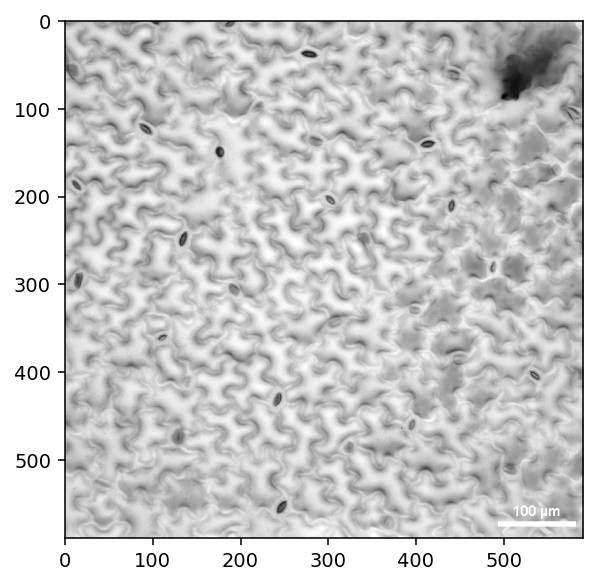

In [5]:
img, path, name = pcv.readimage(args.image)

# Napari to draw boxes

## The following steps would be interactive if done locally. 

## The goal for this image is to segment the stomatal openings. 

![overlay img](./img/bbox.png)

## Section 2: Open napari and draw bounding boxes

1. Run the cell below to open the napari viewer with the image.
2. In the napari viewer, click **New shapes layer** (the rectangle icon in the layer list toolbar).
3. Select the **Rectangle** tool from the shapes toolbar.
4. Draw one or more rectangles around the objects of interest.
5. Note the name of the shapes layer (default is `"Shapes"`).
6. When done, run the next cell to extract the bounding boxes.

In [6]:
#viewer = pcvan.napari_open(img, show=True)
#viewer.add_shapes(name="shapes")

## Section 3: Extract bounding boxes using `napari_bbox`

`pcvan.napari_bbox(viewer, layername)` converts the napari rectangle shapes into bounding boxes formatted as `[x_min, y_min, height, width]`, compatible with SAM.

Set `layername` to match the name of the shapes layer you created in napari (default is `"Shapes"`).

In [7]:
# Set layername to the name of the shapes layer you created
#layername = "shapes"

#bboxes = pcvan.napari_bbox(viewer, layername)
#print("Bounding box(es):")
#print(bboxes)

In [8]:
## napari_bbox returns a single [x, y, h, w] list if one box, or a list of lists if multiple.
## Wrap in a list if needed so SAM always receives a list of boxes.
#if isinstance(bboxes[0], int):
#    bboxes_for_sam = [bboxes]
#else:
#    bboxes_for_sam = bboxes

#print("Bounding boxes passed to SAM:")
#print(bboxes_for_sam)

In [9]:
import pickle

## Save
#with open("bbox.pkl", "wb") as f:
#    pickle.dump(bboxes_for_sam, f)

## Load back
with open("bbox.pkl", "rb") as f:
    bboxes_for_sam = pickle.load(f)

# Using Segment Anything 

## The following codeblock uses the ultralytics package with the Sam3 model downloaded via Hugging Face to segment multiple objects use the bounding box method 

In [10]:
#from ultralytics import SAM
#from ultralytics.models.sam import SAM3SemanticPredictor

#import torch
#print(f"MPS available: {torch.backends.mps.is_available()}")
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")

## Initialize predictor
#overrides = dict(
#    conf=0.25,
#    task="segment",
#    mode="predict",
#    model="./sam3.pt",
#    half=True,
#    save=True,
#)
#predictor = SAM3SemanticPredictor(overrides=overrides)

# Write image to a temp PNG so SAM reads it fresh via cv2 (avoids
# negative-stride errors that occur when passing OME-TIFF numpy arrays
# directly — ultralytics' internal im[..., ::-1] flip re-introduces
# negative strides that torch.from_numpy rejects on MPS).
#tmp_img_path = "./tmp_sam_input.png"
#cv2.imwrite(tmp_img_path, img)
#predictor.set_image(tmp_img_path)

# Run segmentation using bounding boxes from napari_bbox
#results = predictor(bboxes=bboxes_for_sam)


In [11]:
#import pickle
#with open("results.pkl", "wb") as f:
#    pickle.dump(results, f)

In [12]:
import pickle

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

In [13]:
## Section 5: Visualize and overlay results

Min value = 2.0
Max value = 3309.0
Mean value = 839.25


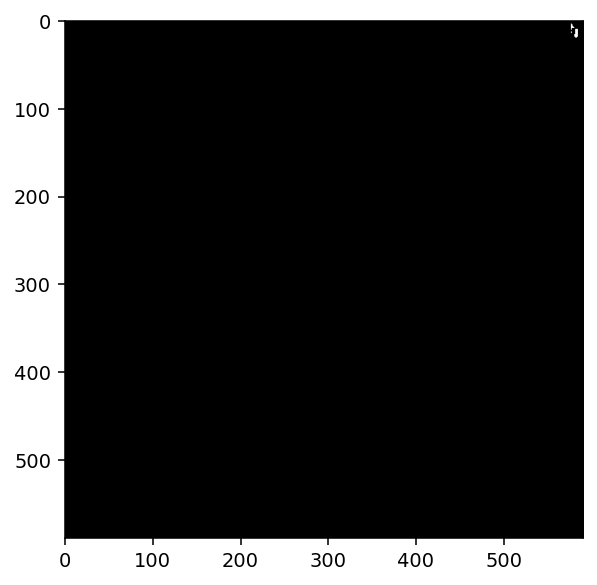

Min value = 146.0
Max value = 146.0
Mean value = 146.0


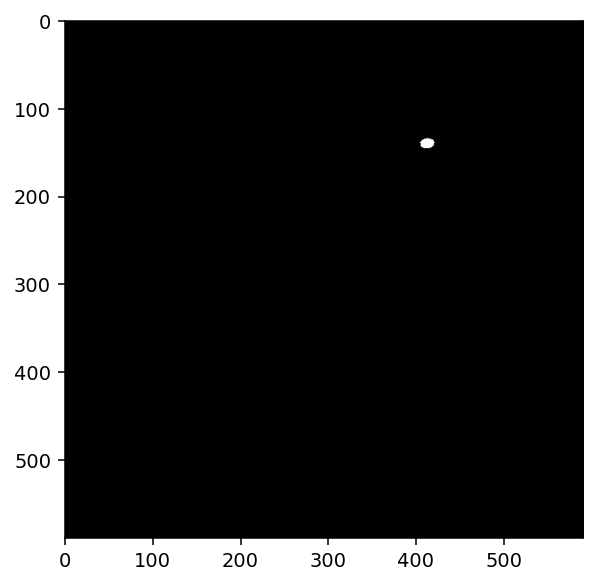

Min value = 39.0
Max value = 39.0
Mean value = 39.0


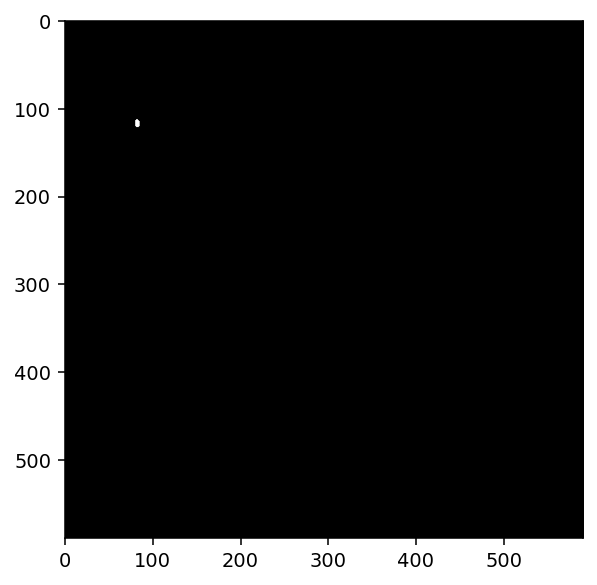

Min value = 30.0
Max value = 30.0
Mean value = 30.0


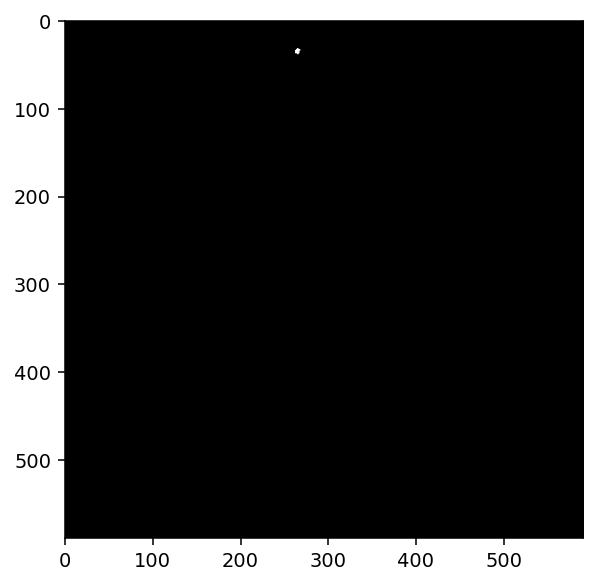

Min value = 157.0
Max value = 157.0
Mean value = 157.0


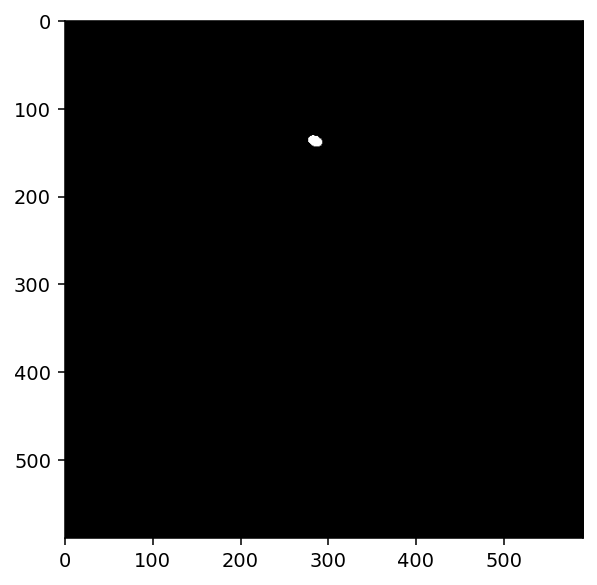

Min value = 69.0
Max value = 69.0
Mean value = 69.0


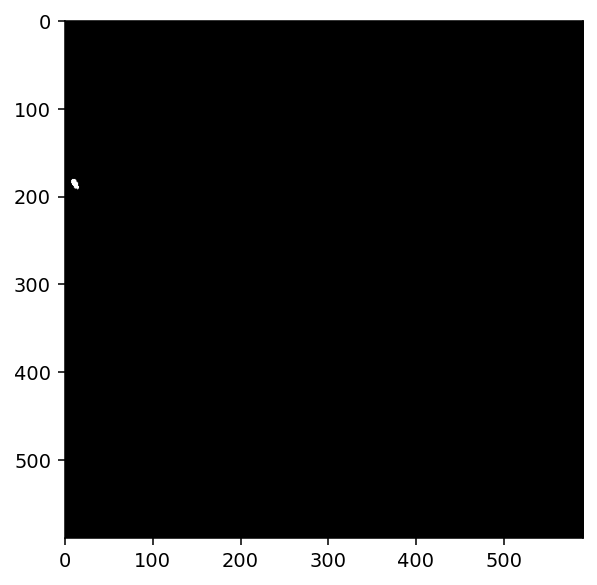

Min value = 178.0
Max value = 178.0
Mean value = 178.0


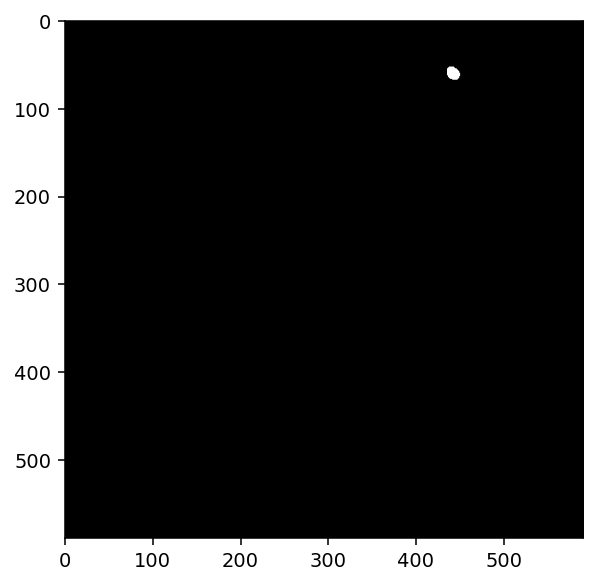

Min value = 42.0
Max value = 42.0
Mean value = 42.0


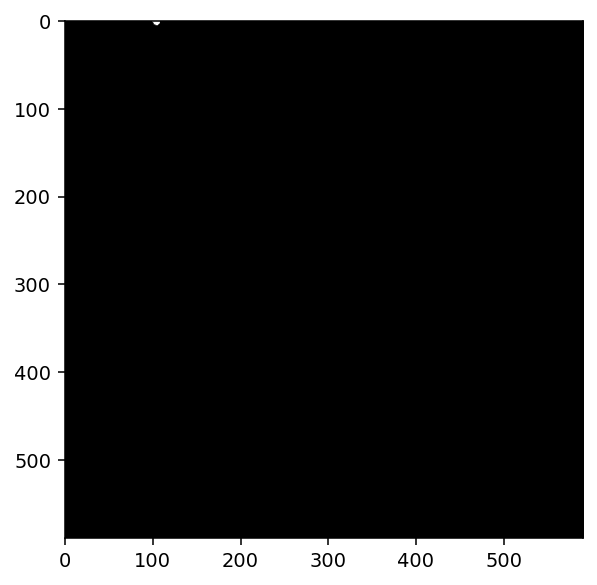

Min value = 50.0
Max value = 50.0
Mean value = 50.0


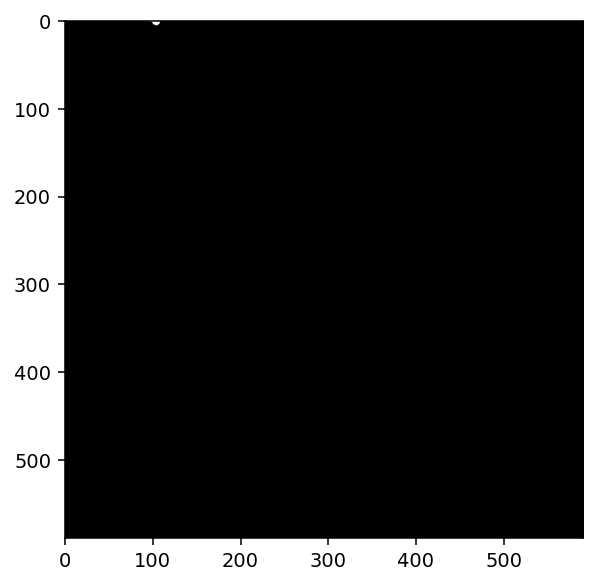

Min value = 119.0
Max value = 119.0
Mean value = 119.0


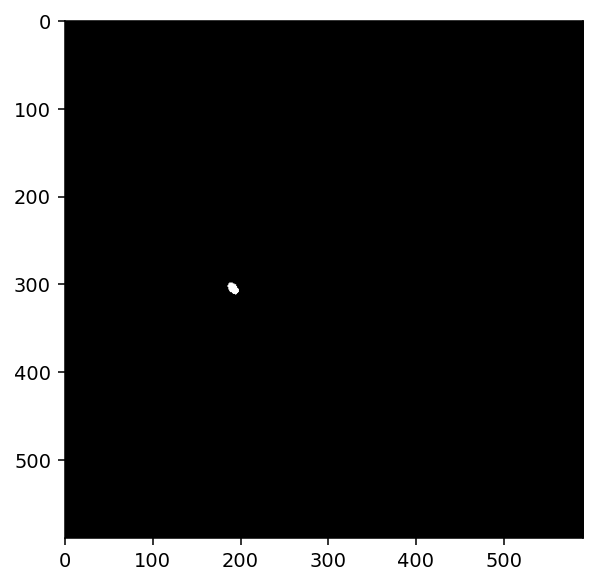

Min value = 127.0
Max value = 127.0
Mean value = 127.0


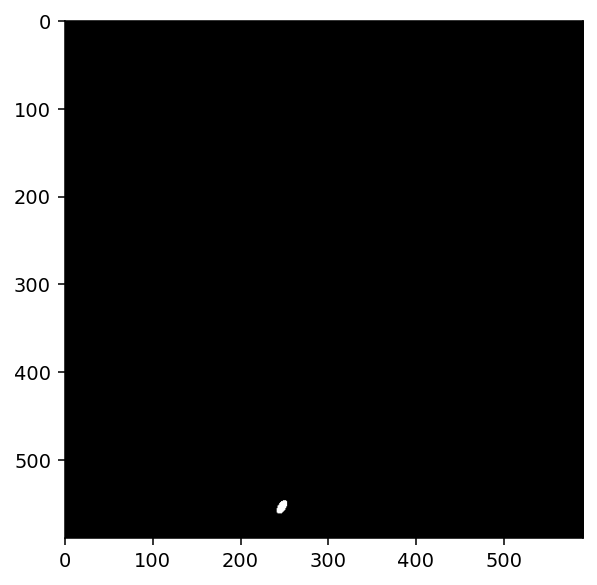

Min value = 67.0
Max value = 67.0
Mean value = 67.0


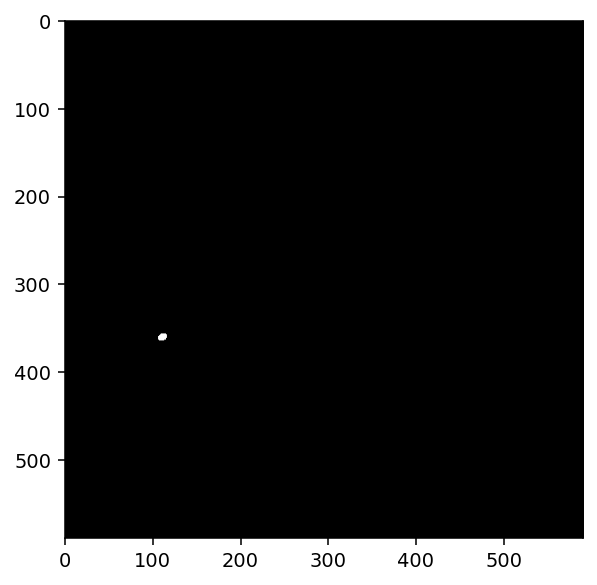

Min value = 24.0
Max value = 24.0
Mean value = 24.0


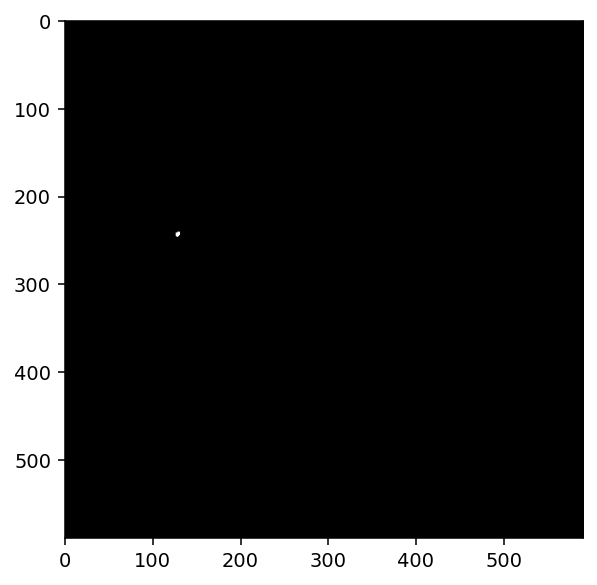

Min value = 214.0
Max value = 214.0
Mean value = 214.0


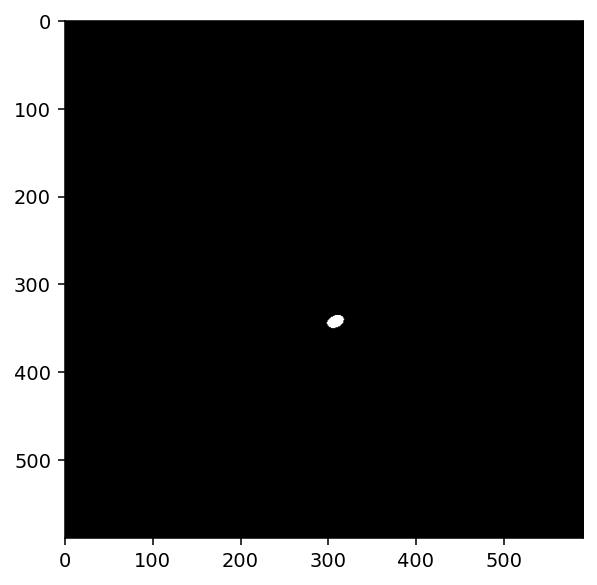

Min value = 119.0
Max value = 119.0
Mean value = 119.0


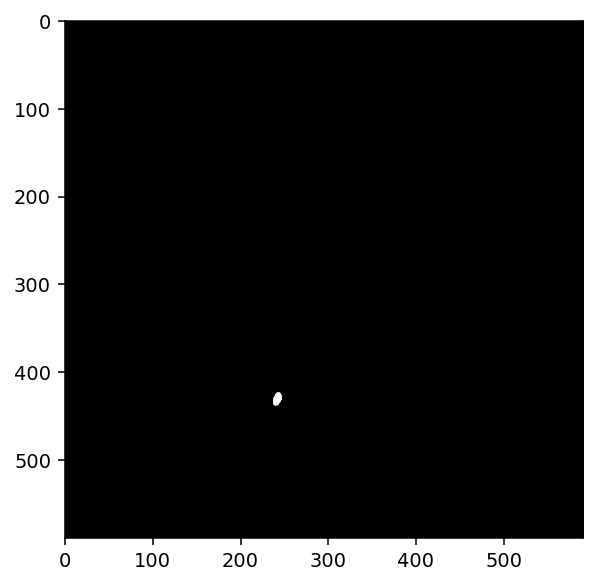

Min value = 176.0
Max value = 176.0
Mean value = 176.0


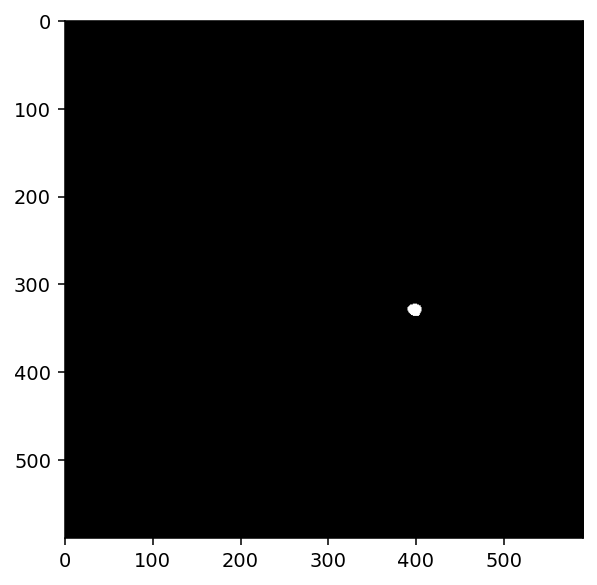

Min value = 94.0
Max value = 94.0
Mean value = 94.0


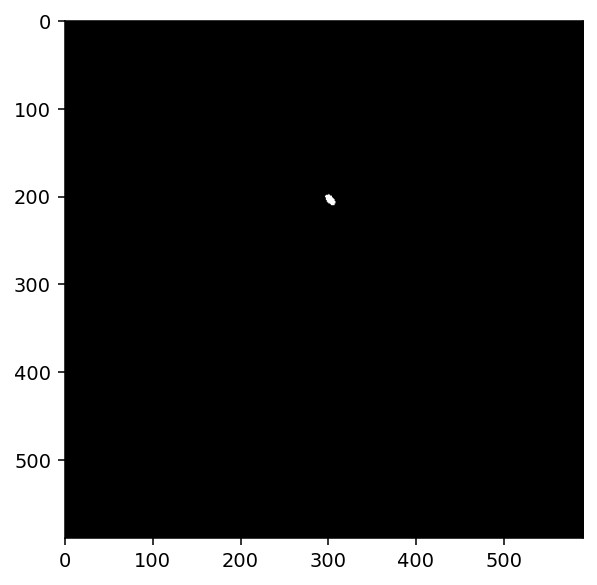

Min value = 157.0
Max value = 157.0
Mean value = 157.0


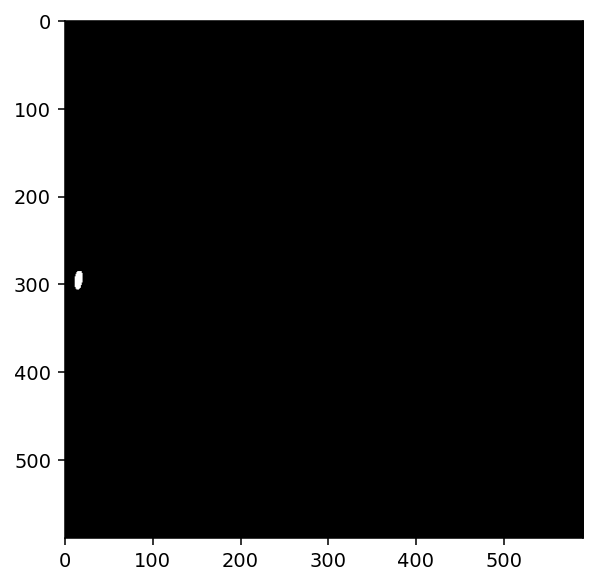

Min value = 80.0
Max value = 80.0
Mean value = 80.0


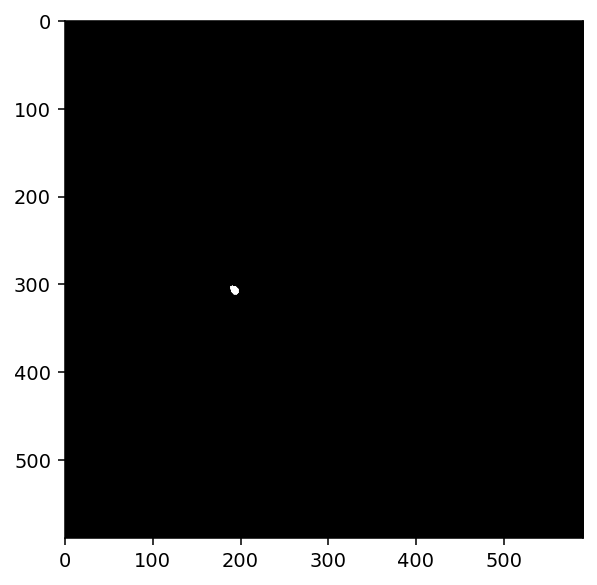

Min value = 81.0
Max value = 81.0
Mean value = 81.0


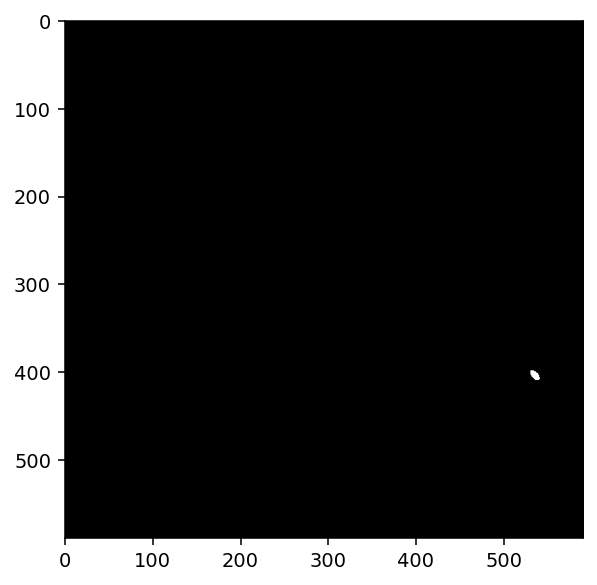

Min value = 81.0
Max value = 81.0
Mean value = 81.0


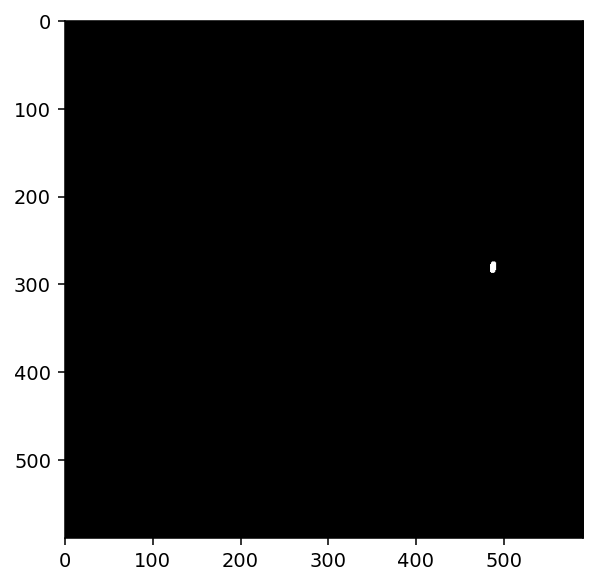

Min value = 41.0
Max value = 41.0
Mean value = 41.0


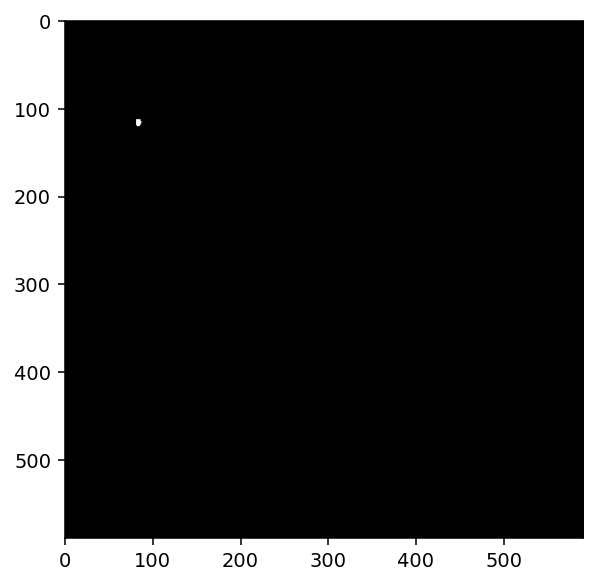

Min value = 283.0
Max value = 283.0
Mean value = 283.0


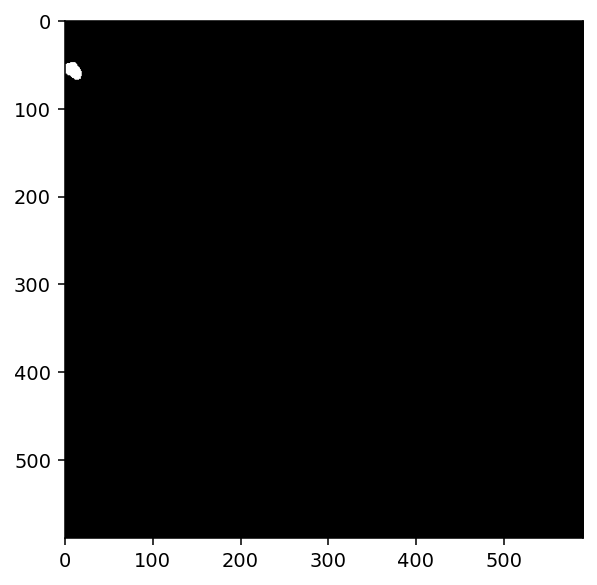

Min value = 263.0
Max value = 263.0
Mean value = 263.0


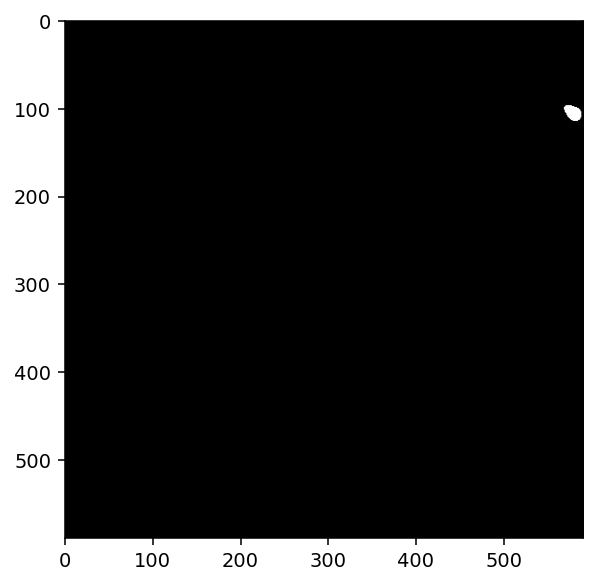

Min value = 25.0
Max value = 25.0
Mean value = 25.0


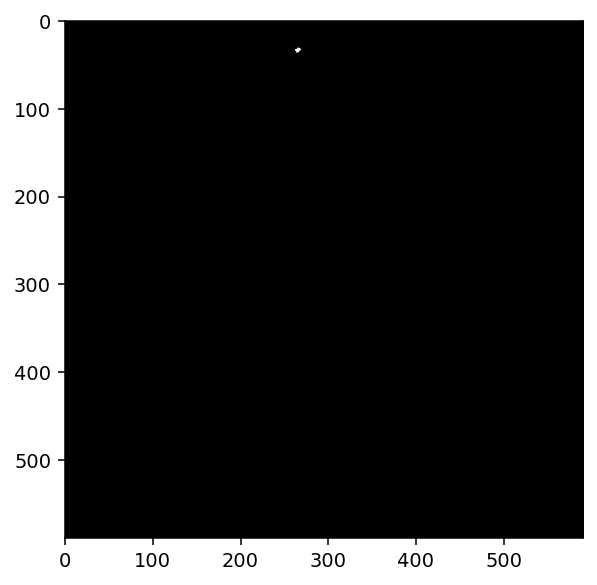

Min value = 163.0
Max value = 163.0
Mean value = 163.0


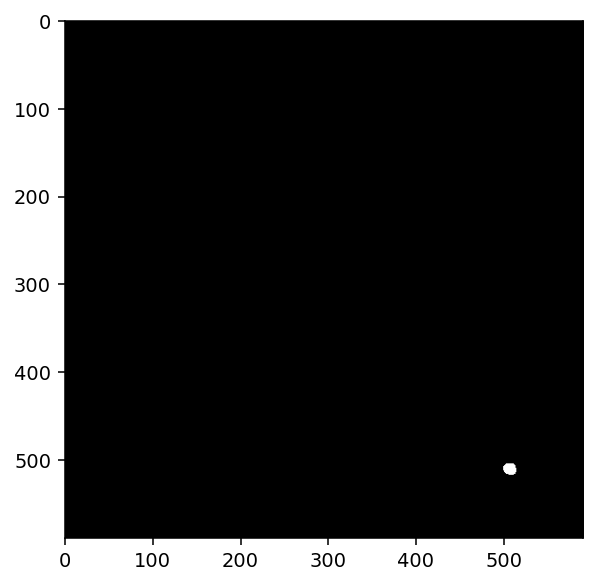

Min value = 117.0
Max value = 117.0
Mean value = 117.0


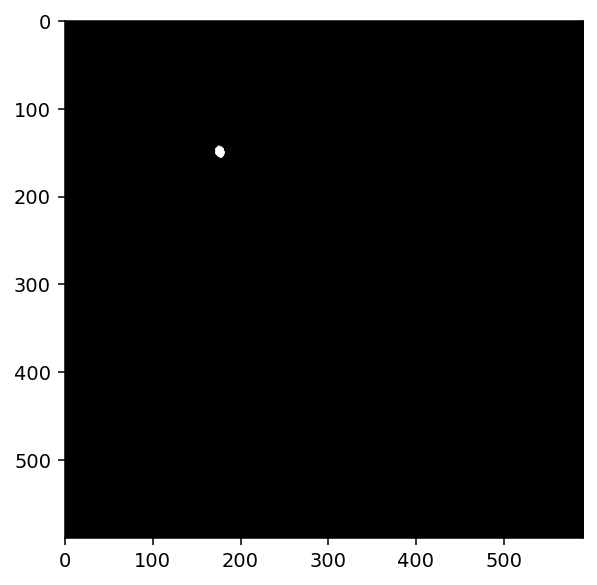

Min value = 95.0
Max value = 95.0
Mean value = 95.0


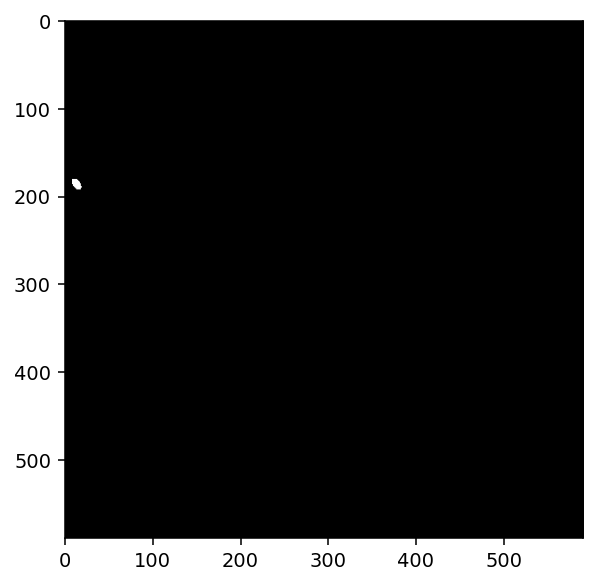

Min value = 21.0
Max value = 21.0
Mean value = 21.0


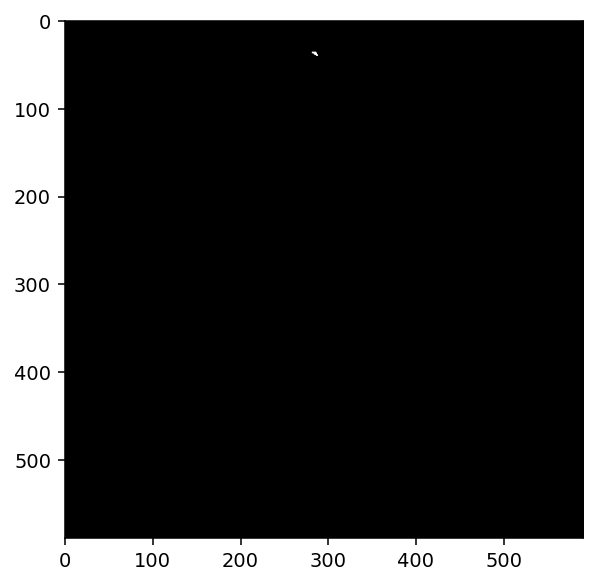

Min value = 111.0
Max value = 111.0
Mean value = 111.0


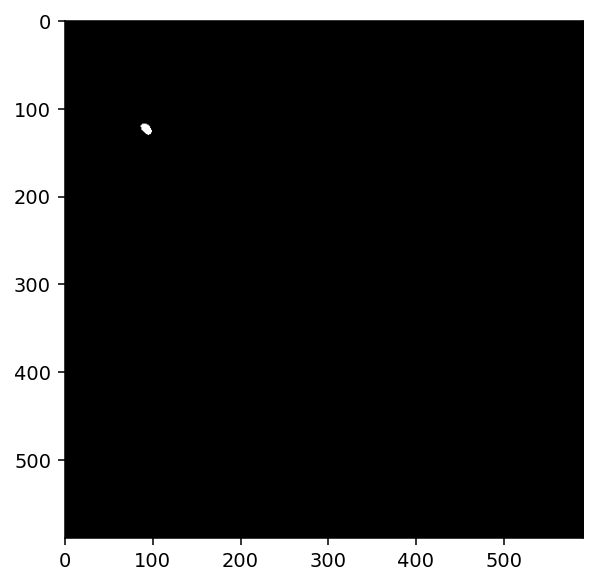

Min value = 92.0
Max value = 92.0
Mean value = 92.0


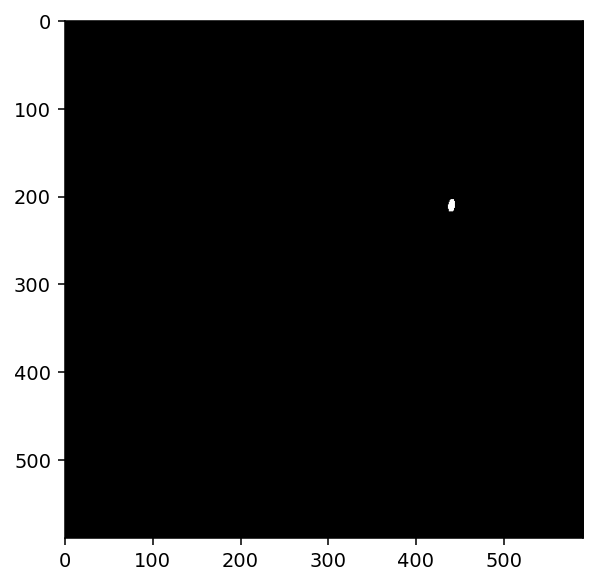

Min value = 130.0
Max value = 130.0
Mean value = 130.0


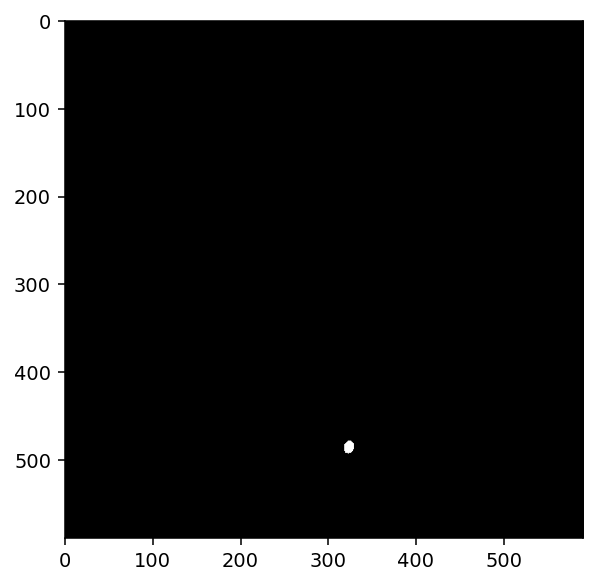

Min value = 66.0
Max value = 66.0
Mean value = 66.0


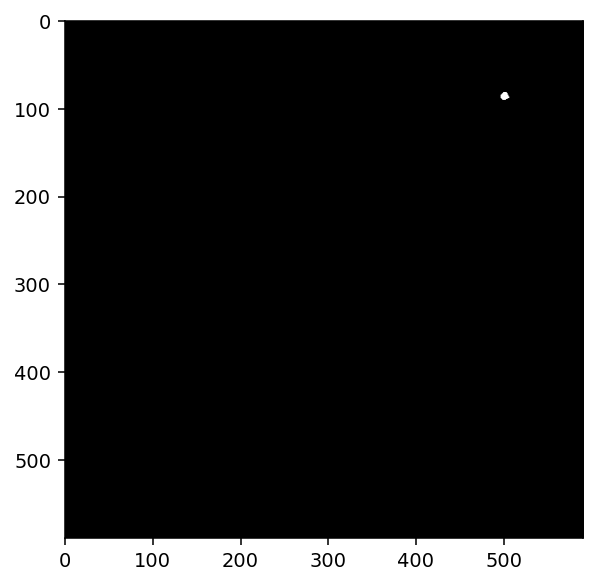

Min value = 77.0
Max value = 77.0
Mean value = 77.0


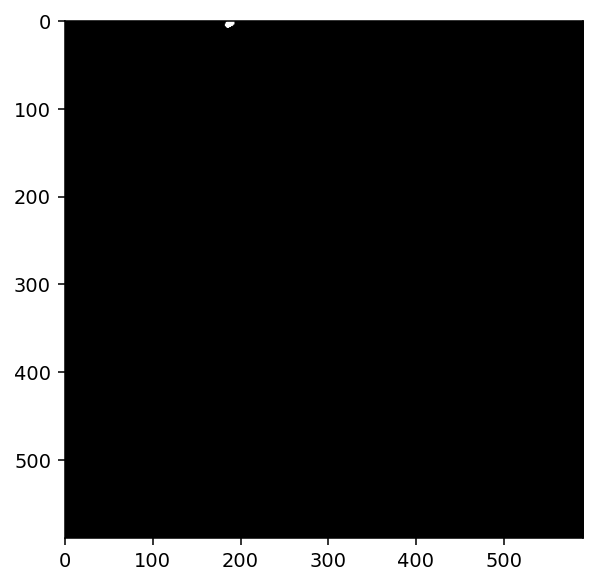

Min value = 19.0
Max value = 19.0
Mean value = 19.0


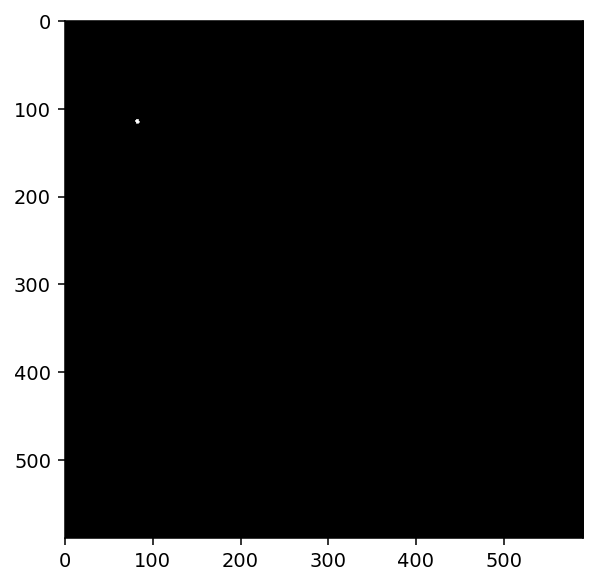

Min value = 58.0
Max value = 58.0
Mean value = 58.0


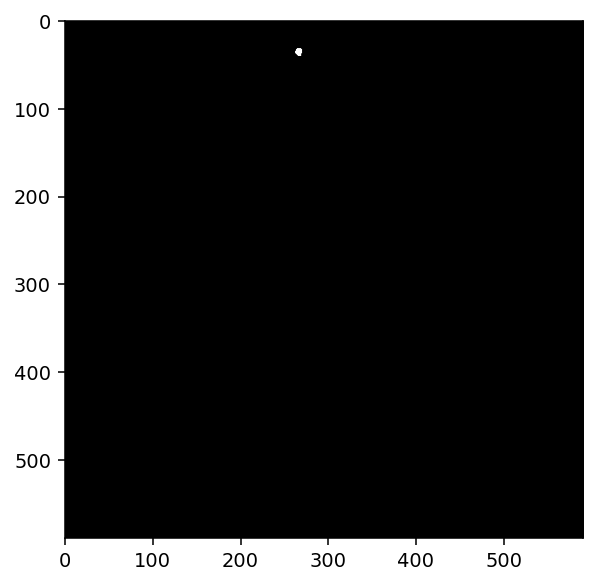

Min value = 78.0
Max value = 78.0
Mean value = 78.0


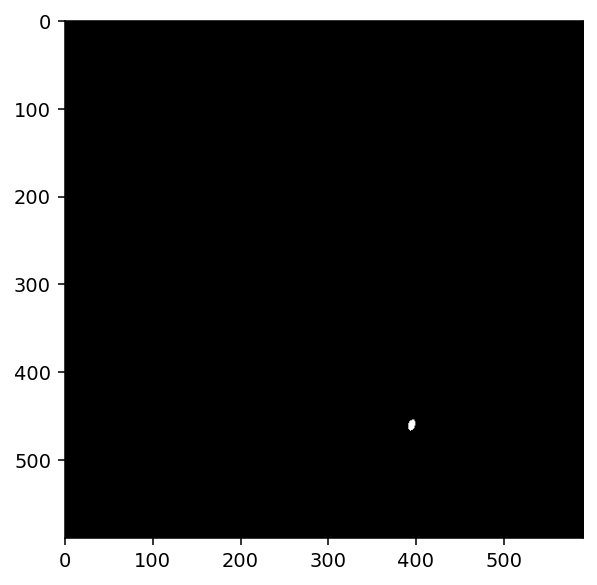

Min value = 142.0
Max value = 142.0
Mean value = 142.0


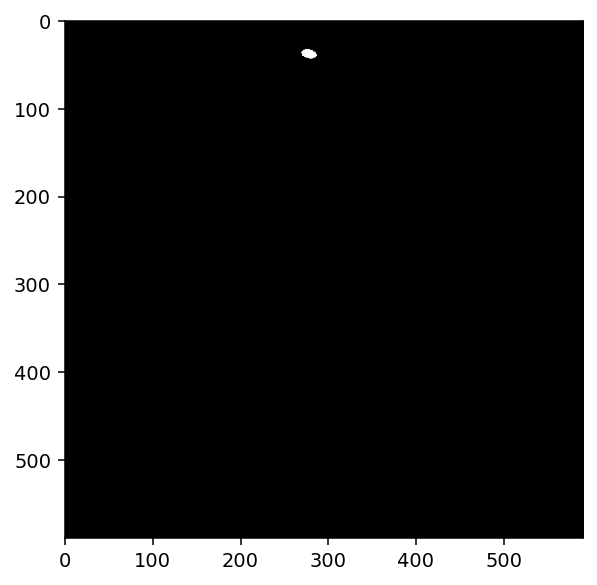

Min value = 208.0
Max value = 208.0
Mean value = 208.0


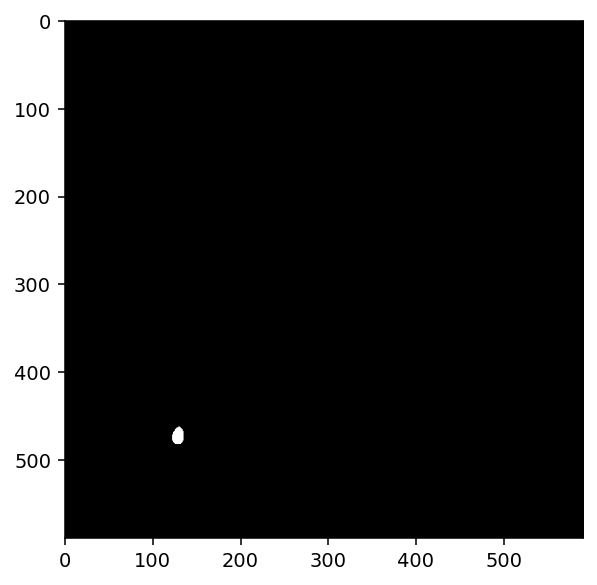

Min value = 174.0
Max value = 174.0
Mean value = 174.0


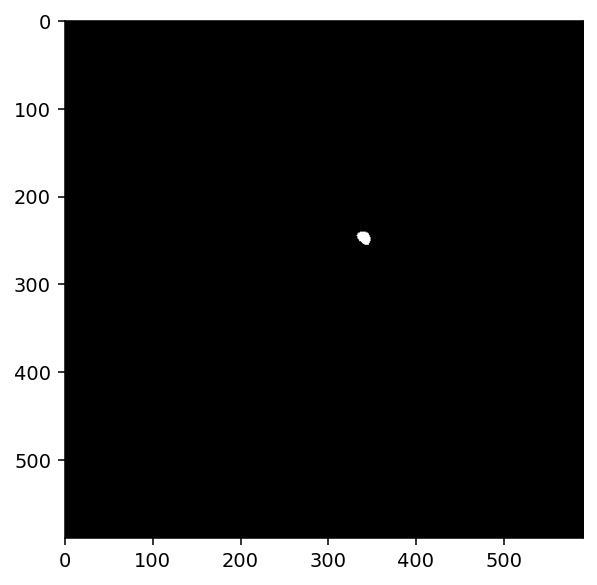

Min value = 1234.0
Max value = 1234.0
Mean value = 1234.0


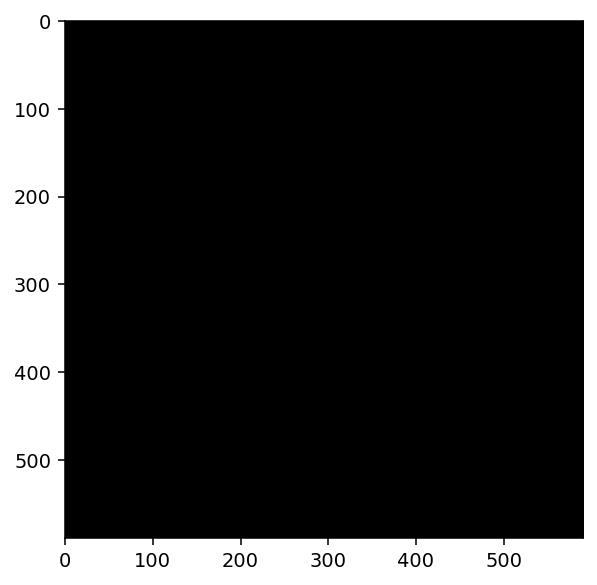

Min value = 112.0
Max value = 112.0
Mean value = 112.0


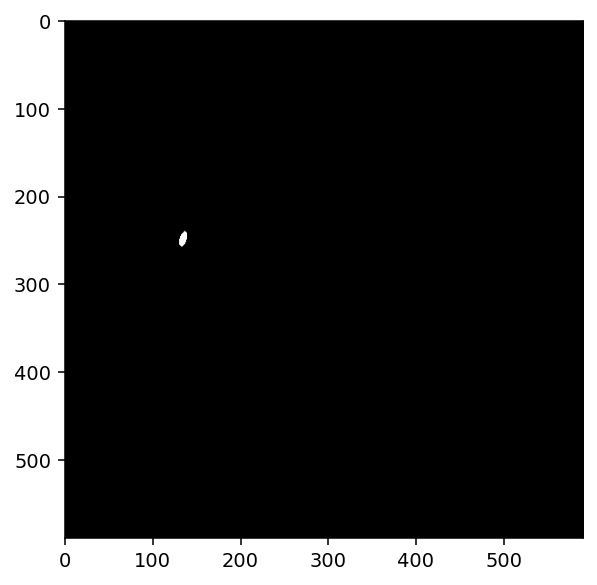

Min value = 60.0
Max value = 60.0
Mean value = 60.0


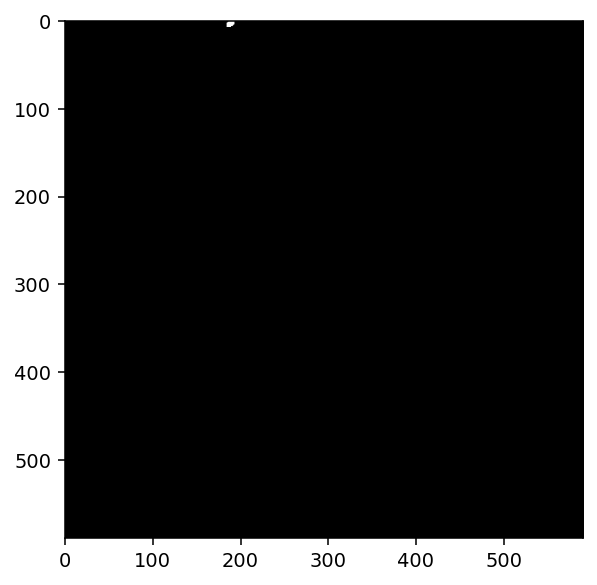

Min value = 80.0
Max value = 80.0
Mean value = 80.0


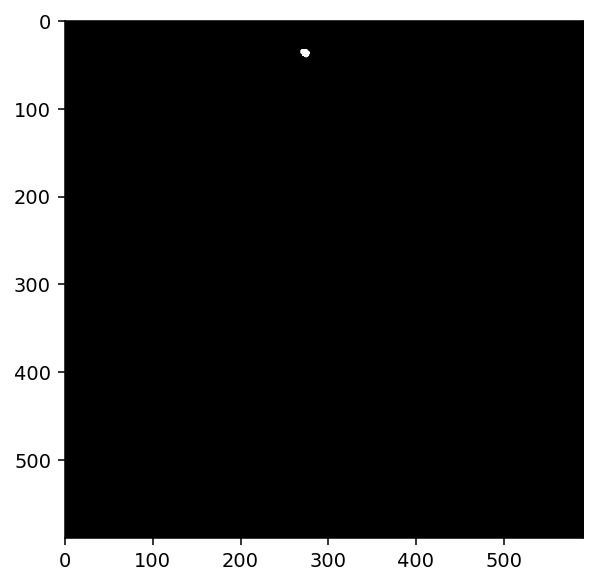

Min value = 2.0
Max value = 32.0
Mean value = 16.0


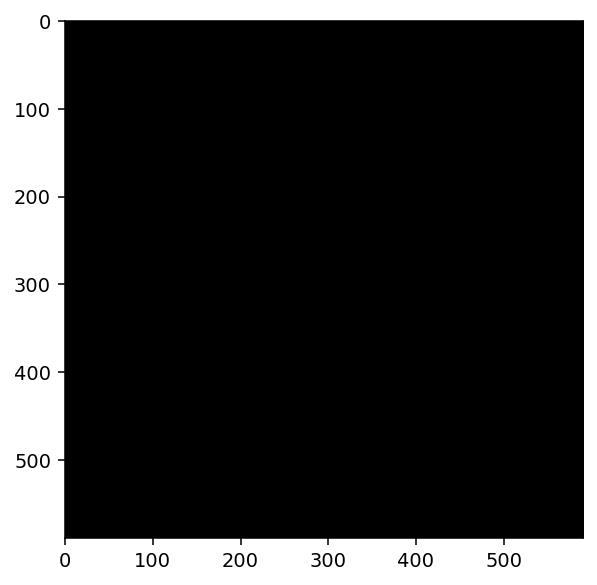

Min value = 146.0
Max value = 146.0
Mean value = 146.0


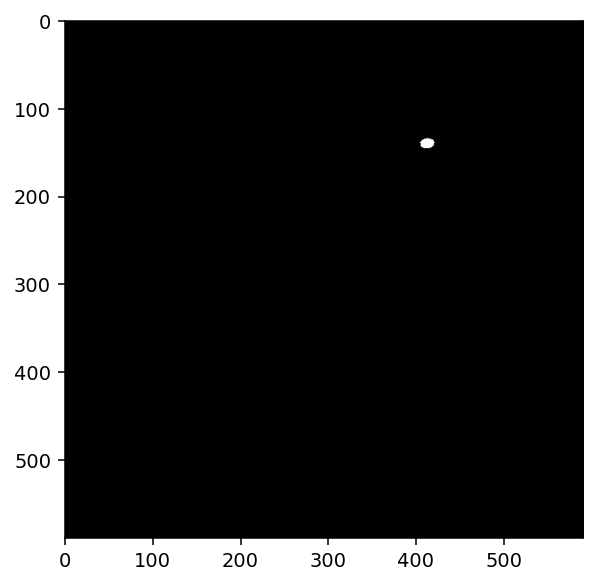

Min value = 39.0
Max value = 39.0
Mean value = 39.0


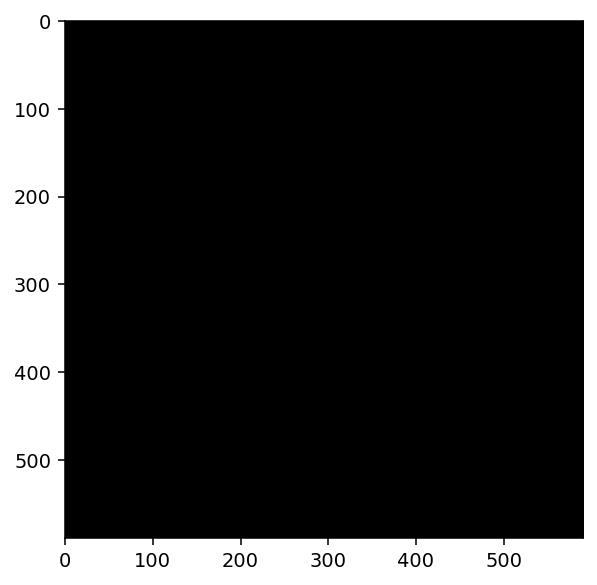

Min value = 30.0
Max value = 30.0
Mean value = 30.0


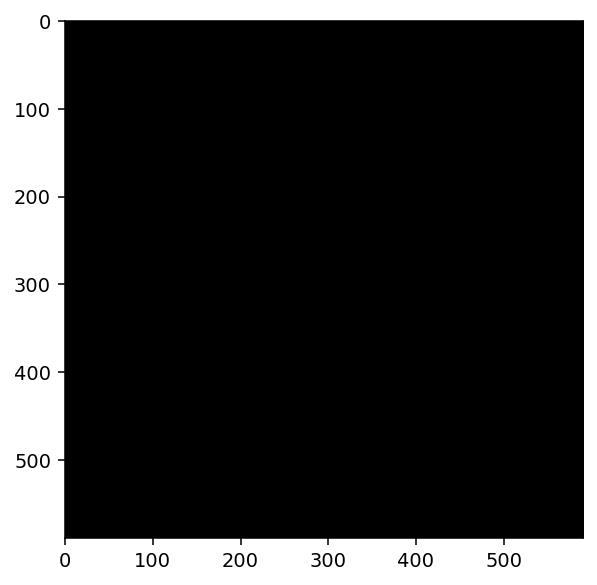

Min value = 157.0
Max value = 157.0
Mean value = 157.0


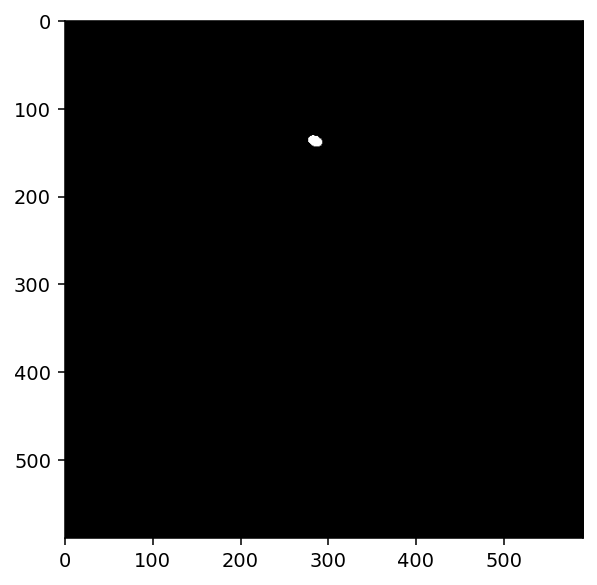

Min value = 69.0
Max value = 69.0
Mean value = 69.0


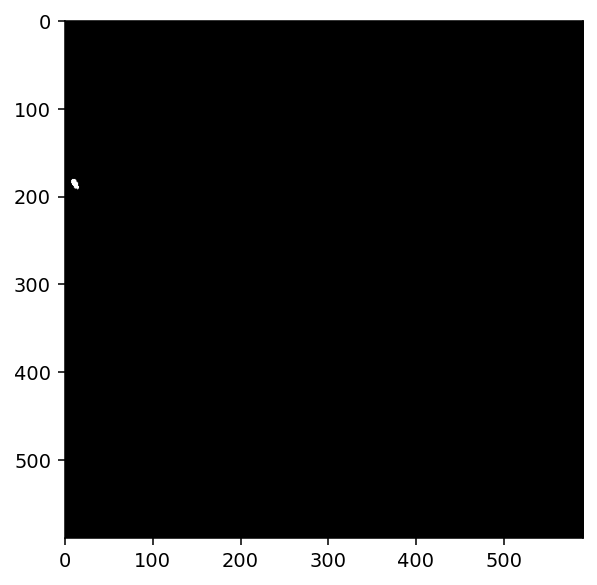

Min value = 178.0
Max value = 178.0
Mean value = 178.0


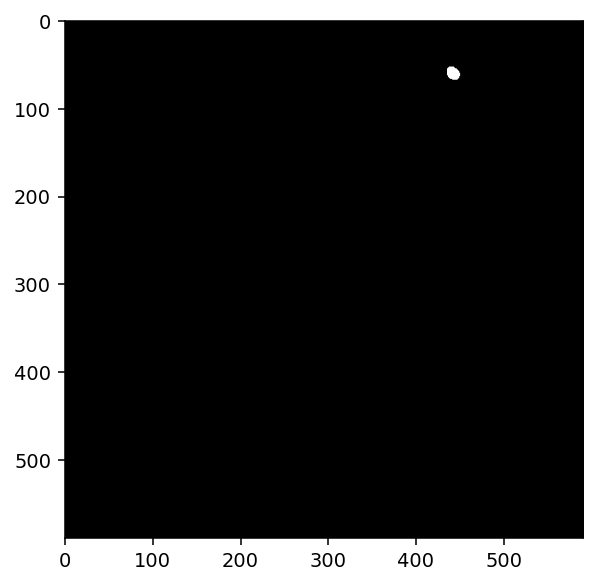

Min value = 42.0
Max value = 42.0
Mean value = 42.0


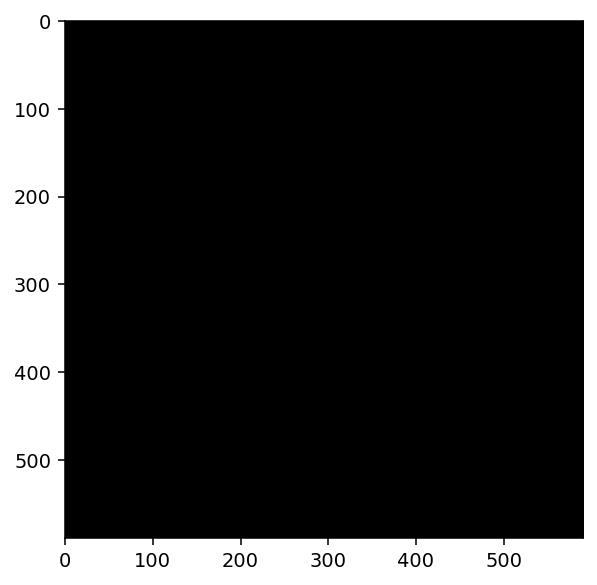

Min value = 50.0
Max value = 50.0
Mean value = 50.0


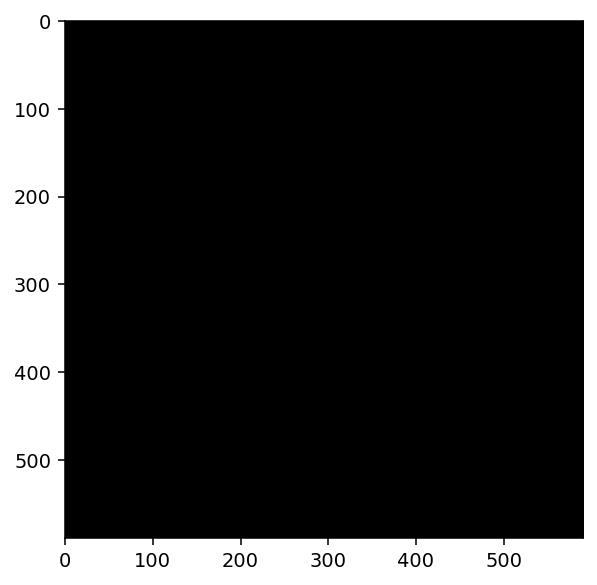

Min value = 119.0
Max value = 119.0
Mean value = 119.0


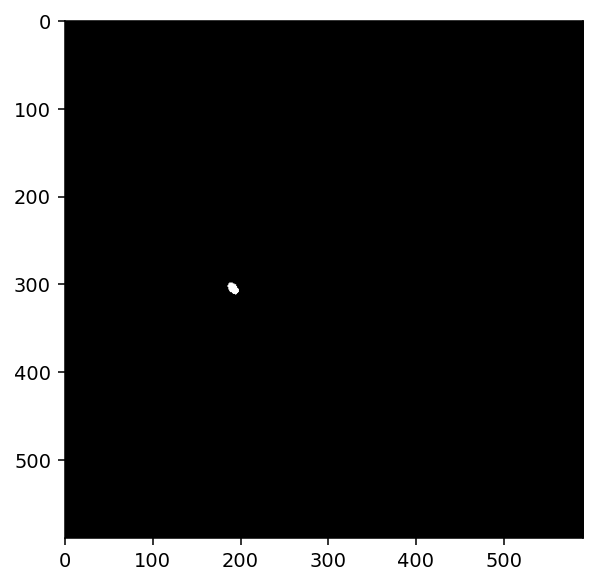

Min value = 127.0
Max value = 127.0
Mean value = 127.0


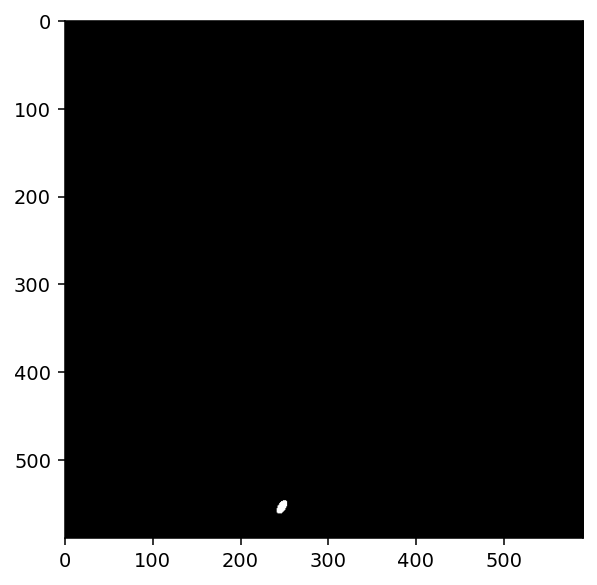

Min value = 67.0
Max value = 67.0
Mean value = 67.0


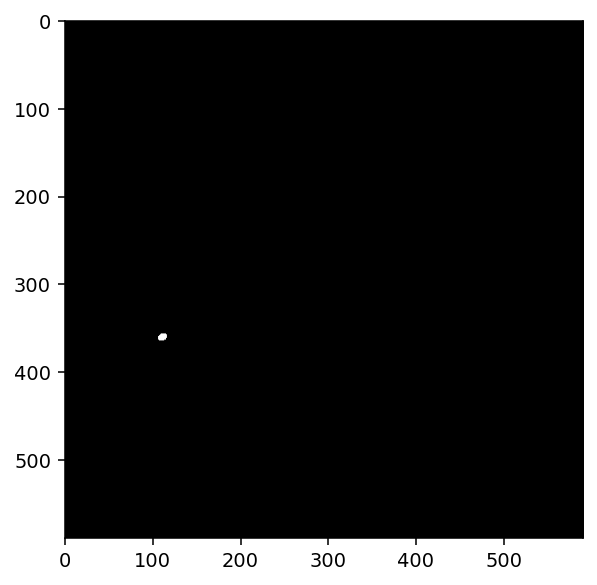

Min value = 24.0
Max value = 24.0
Mean value = 24.0


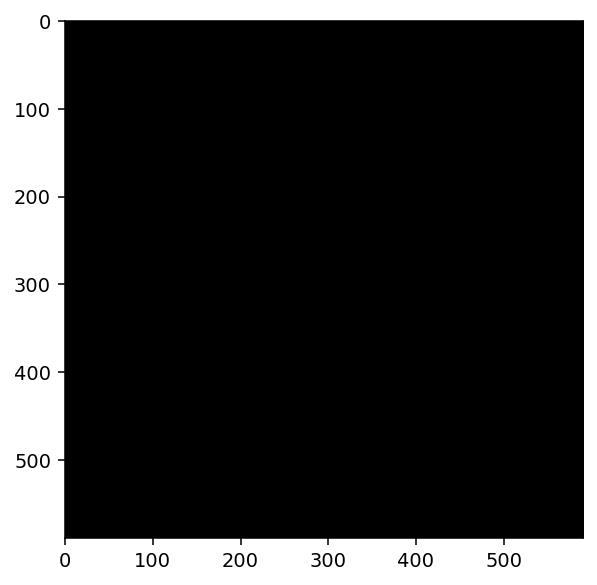

Min value = 214.0
Max value = 214.0
Mean value = 214.0


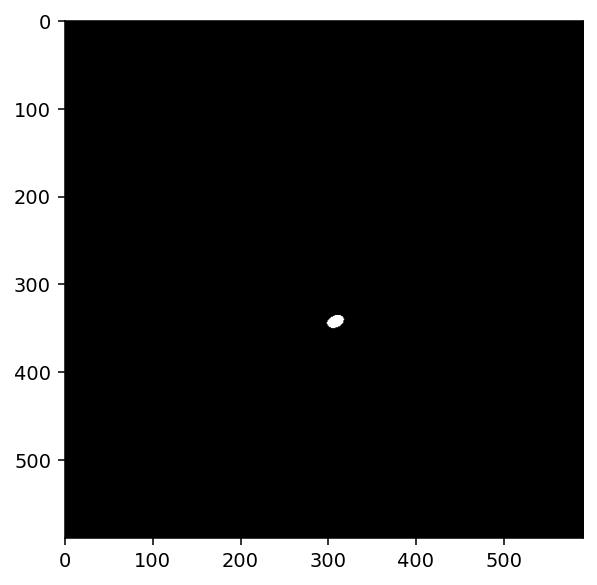

Min value = 119.0
Max value = 119.0
Mean value = 119.0


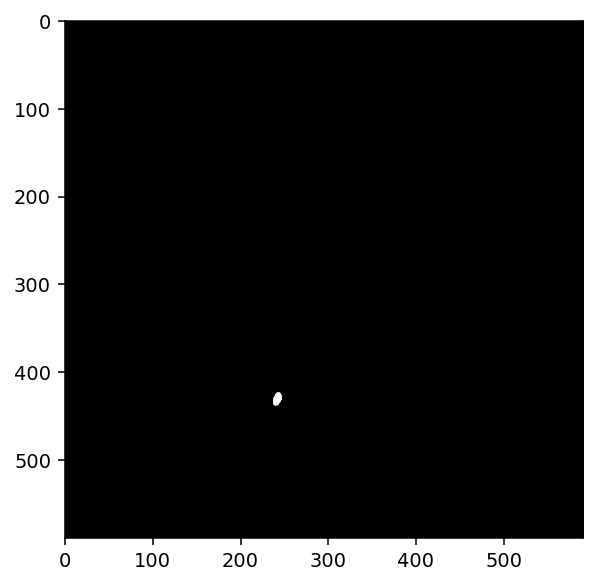

Min value = 176.0
Max value = 176.0
Mean value = 176.0


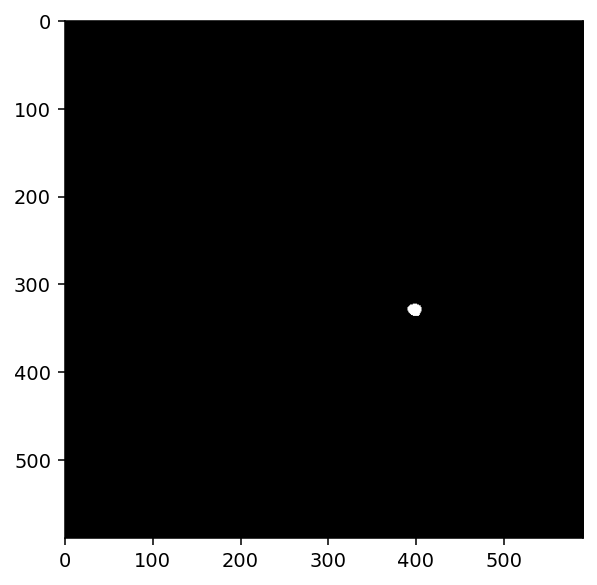

Min value = 94.0
Max value = 94.0
Mean value = 94.0


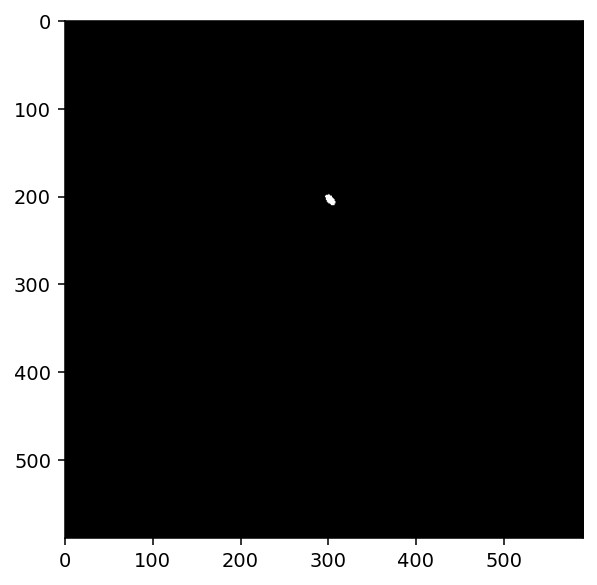

Min value = 157.0
Max value = 157.0
Mean value = 157.0


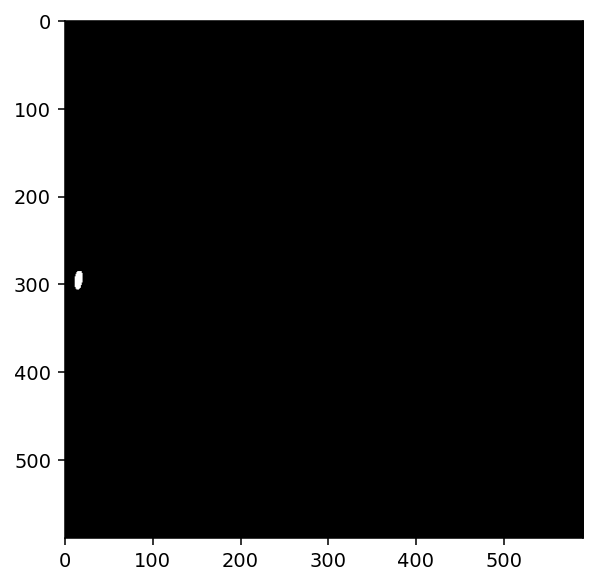

Min value = 80.0
Max value = 80.0
Mean value = 80.0


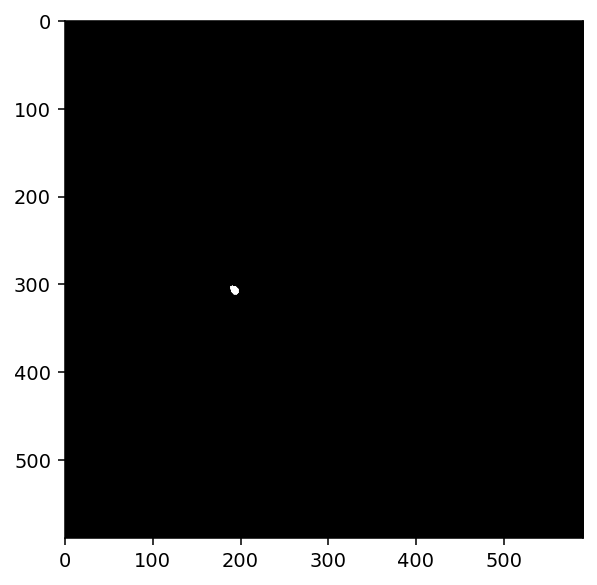

Min value = 81.0
Max value = 81.0
Mean value = 81.0


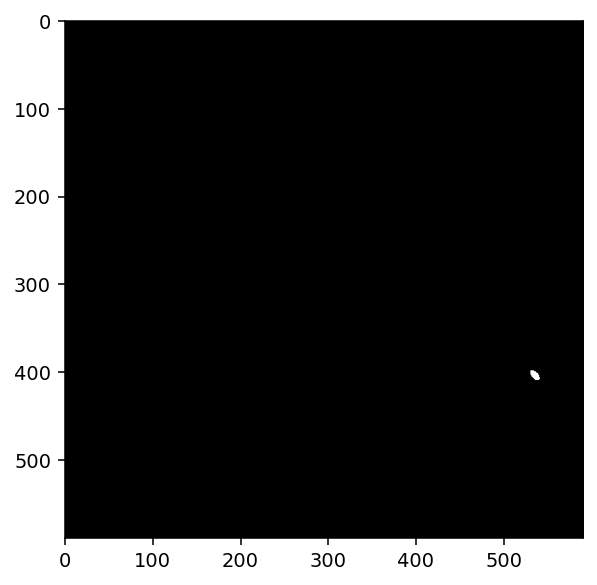

Min value = 81.0
Max value = 81.0
Mean value = 81.0


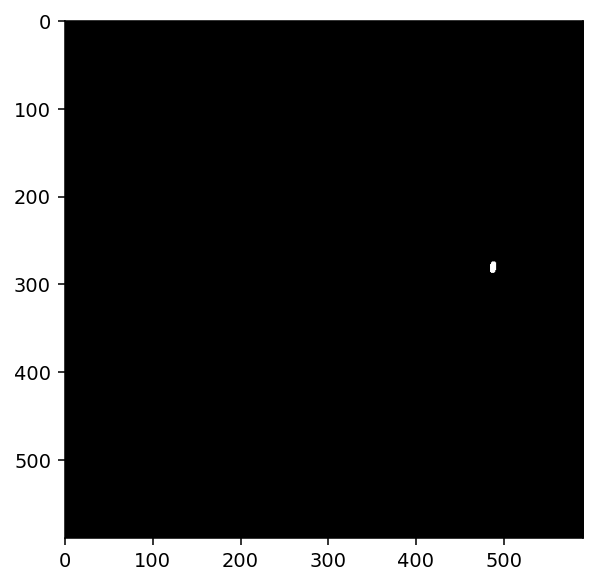

Min value = 41.0
Max value = 41.0
Mean value = 41.0


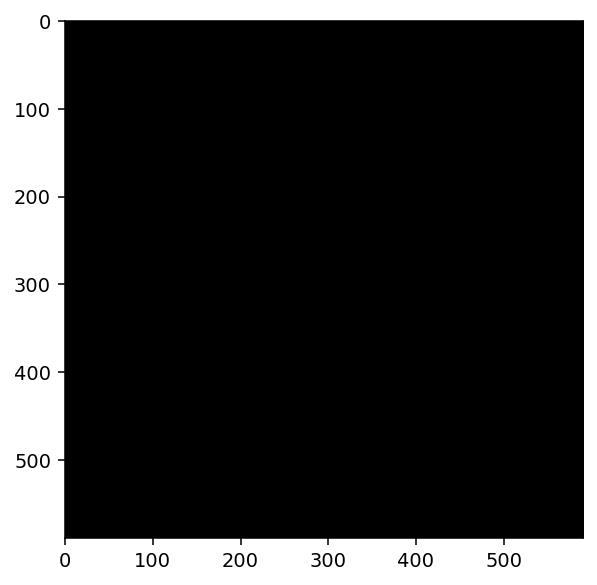

Min value = 283.0
Max value = 283.0
Mean value = 283.0


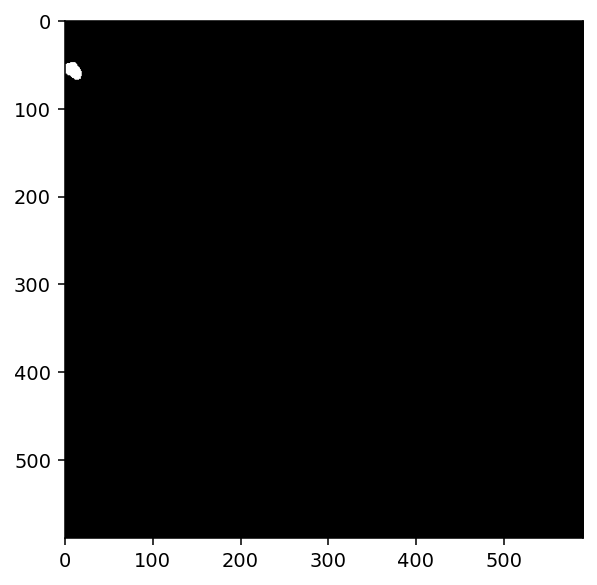

Min value = 263.0
Max value = 263.0
Mean value = 263.0


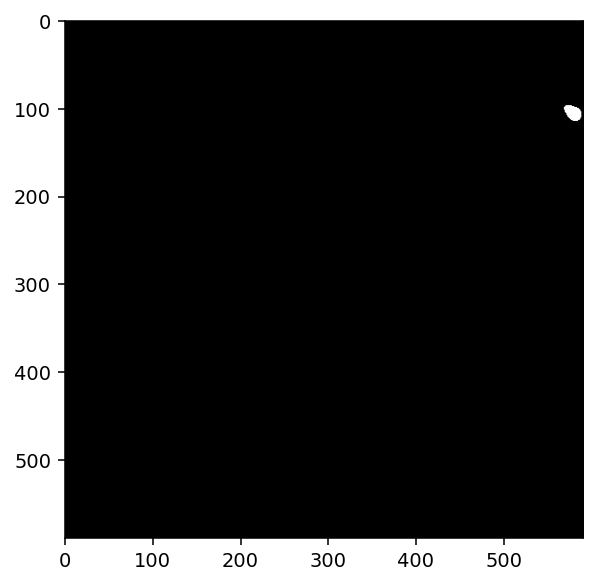

Min value = 25.0
Max value = 25.0
Mean value = 25.0


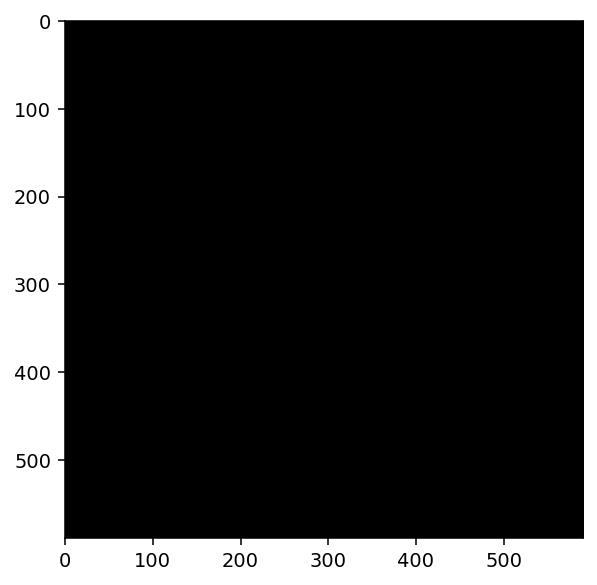

Min value = 163.0
Max value = 163.0
Mean value = 163.0


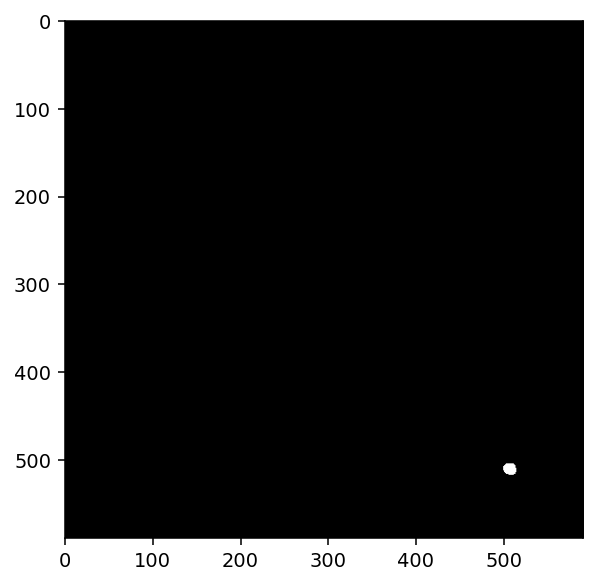

Min value = 117.0
Max value = 117.0
Mean value = 117.0


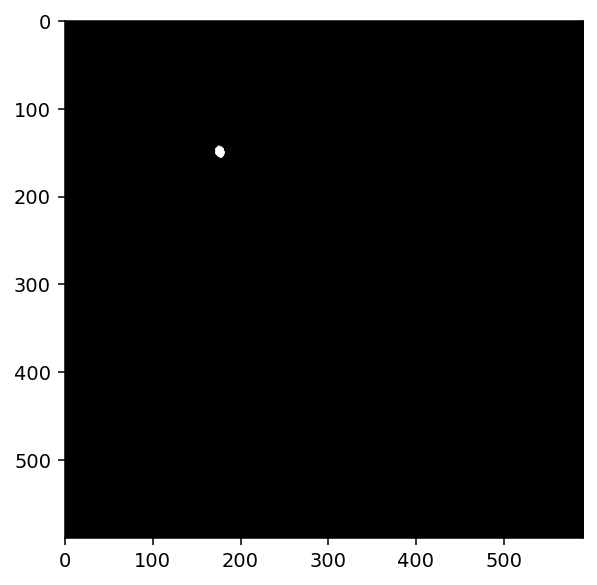

Min value = 95.0
Max value = 95.0
Mean value = 95.0


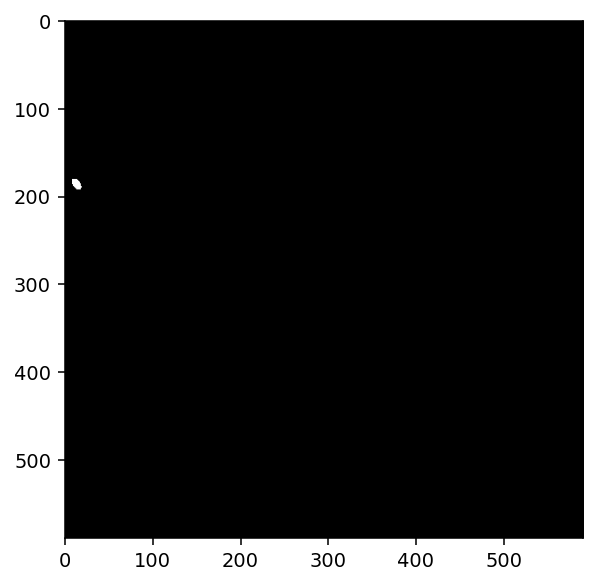

Min value = 21.0
Max value = 21.0
Mean value = 21.0


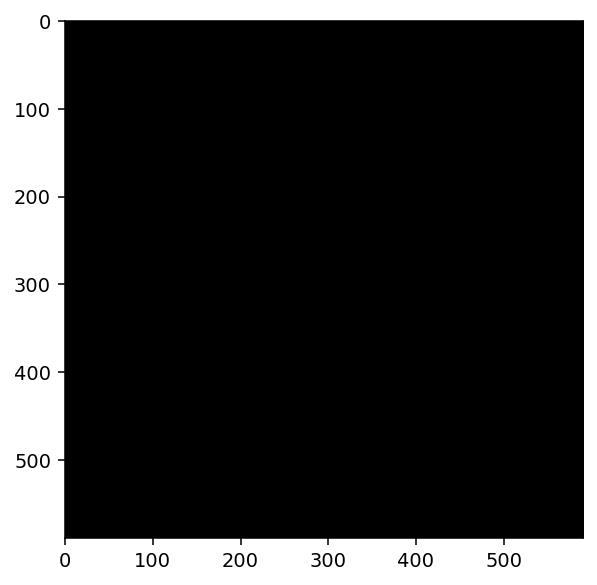

Min value = 111.0
Max value = 111.0
Mean value = 111.0


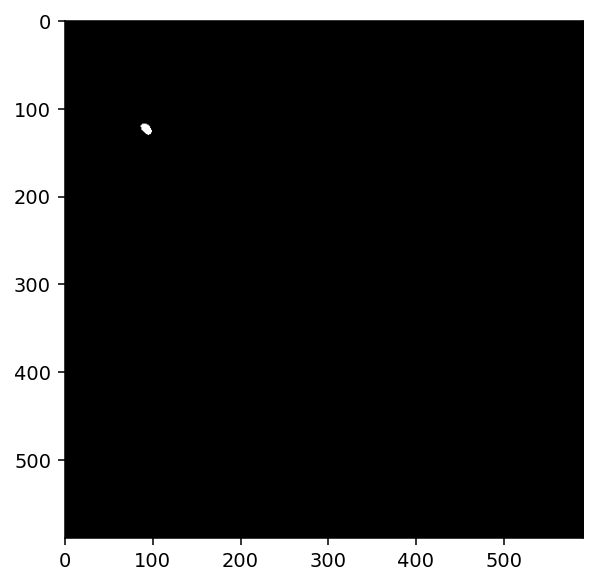

Min value = 92.0
Max value = 92.0
Mean value = 92.0


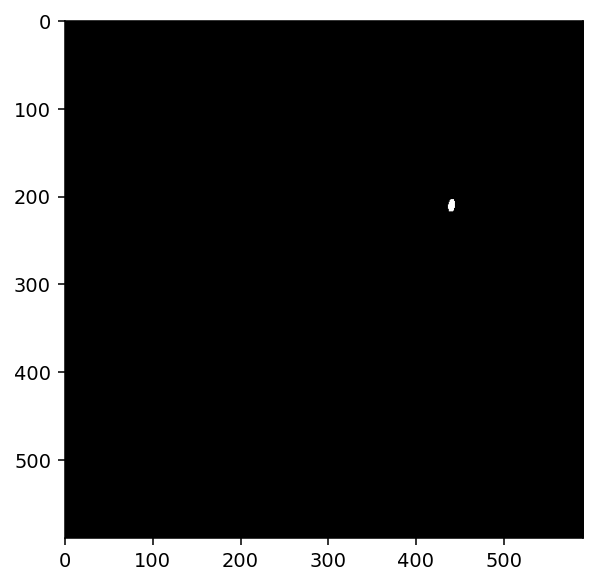

Min value = 130.0
Max value = 130.0
Mean value = 130.0


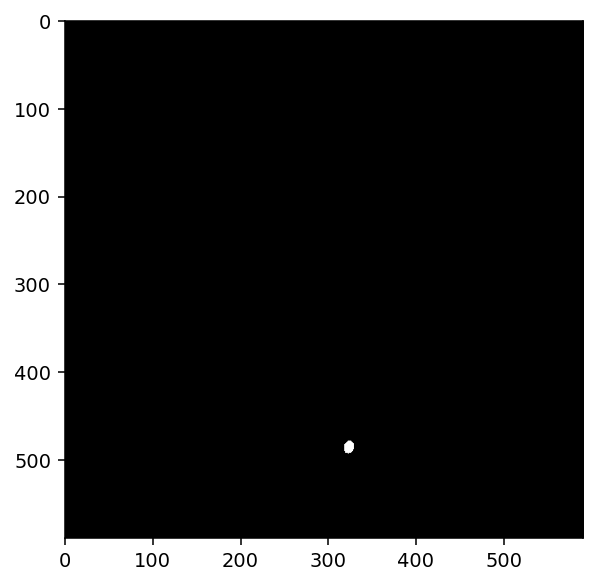

Min value = 66.0
Max value = 66.0
Mean value = 66.0


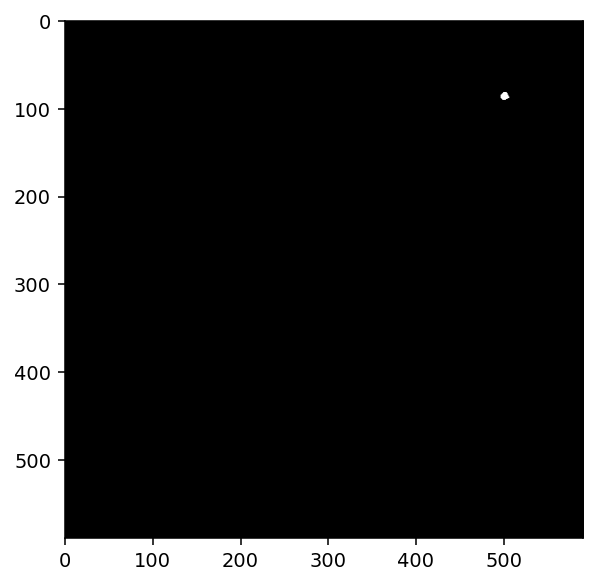

Min value = 77.0
Max value = 77.0
Mean value = 77.0


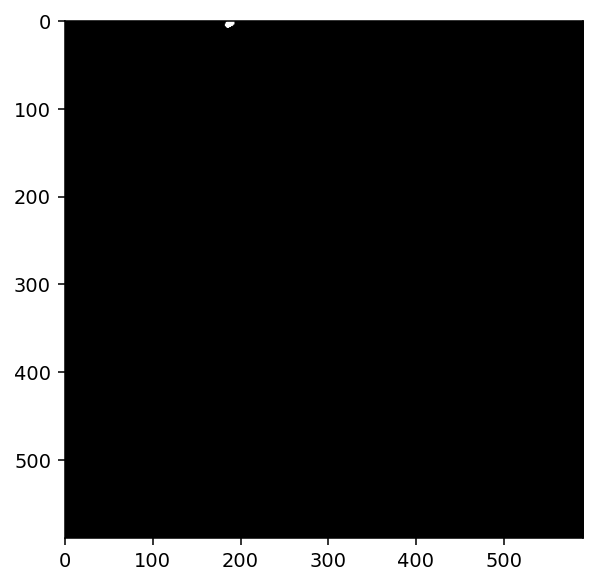

Min value = 19.0
Max value = 19.0
Mean value = 19.0


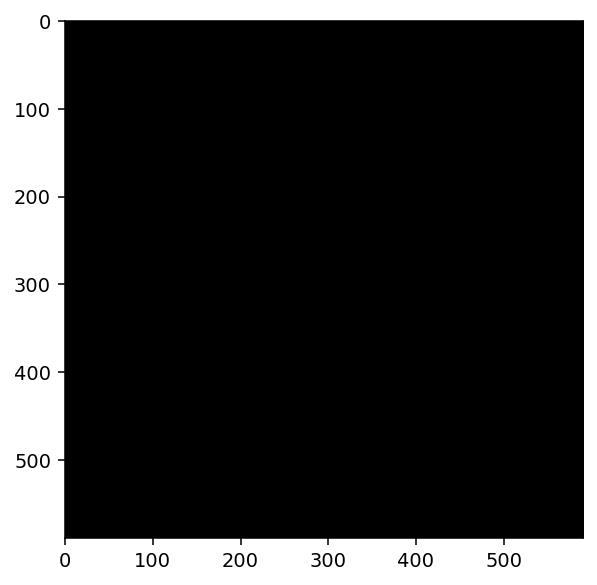

Min value = 58.0
Max value = 58.0
Mean value = 58.0


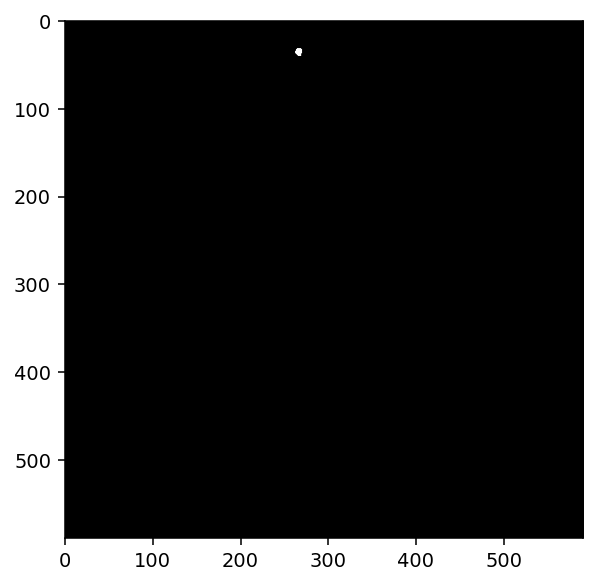

Min value = 78.0
Max value = 78.0
Mean value = 78.0


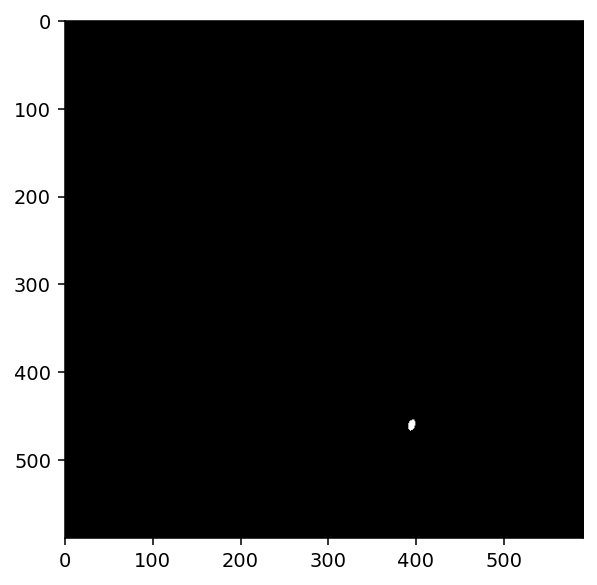

Min value = 142.0
Max value = 142.0
Mean value = 142.0


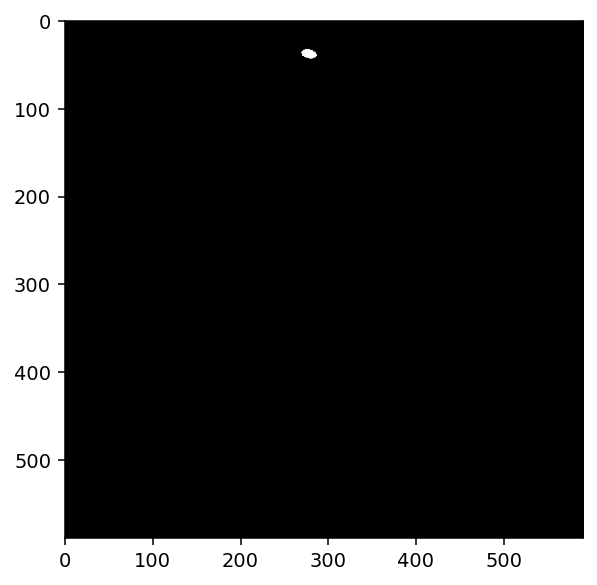

Min value = 208.0
Max value = 208.0
Mean value = 208.0


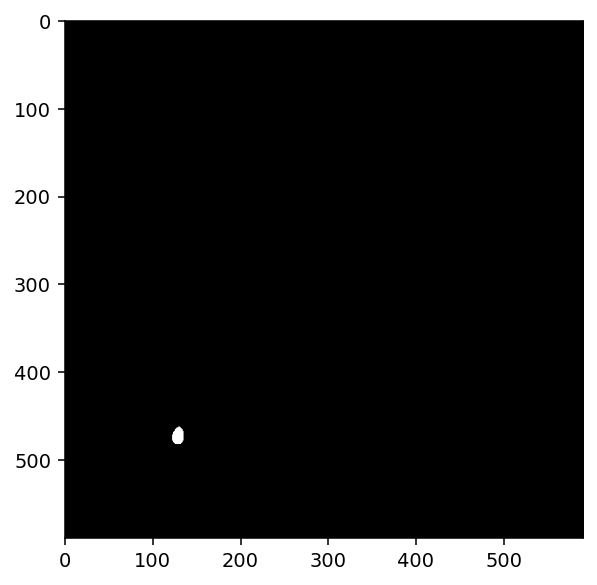

Min value = 174.0
Max value = 174.0
Mean value = 174.0


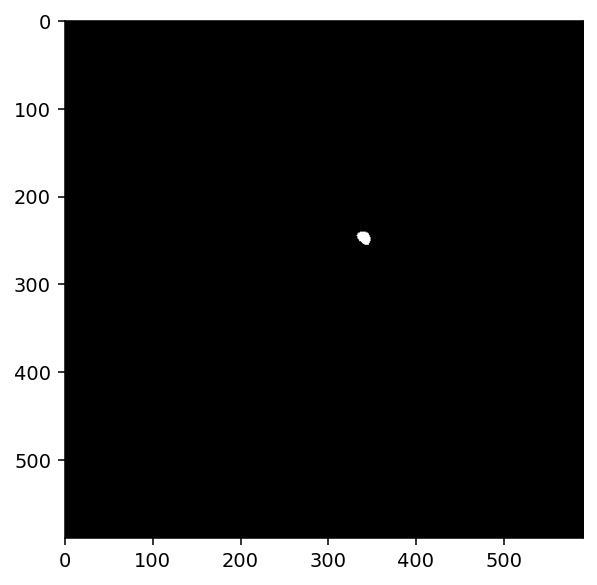

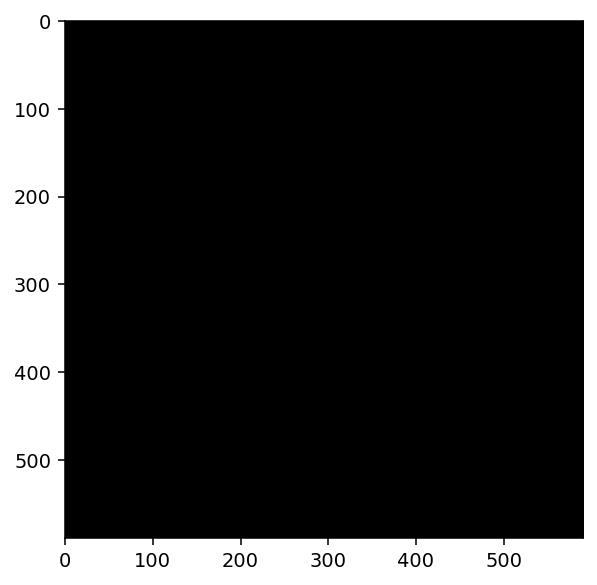

Min value = 112.0
Max value = 112.0
Mean value = 112.0


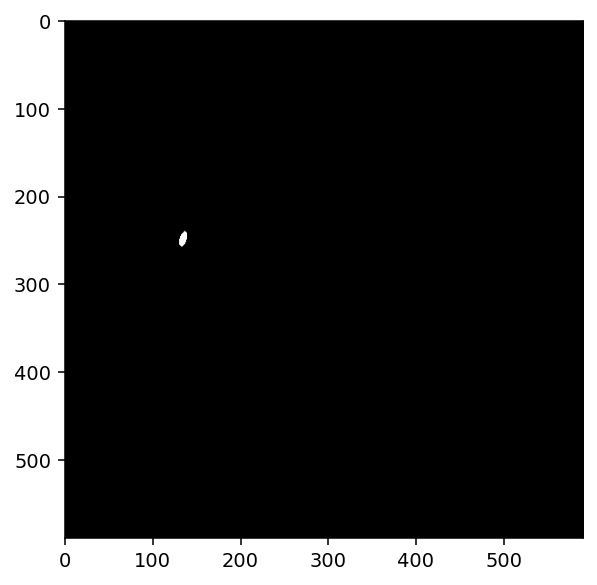

Min value = 60.0
Max value = 60.0
Mean value = 60.0


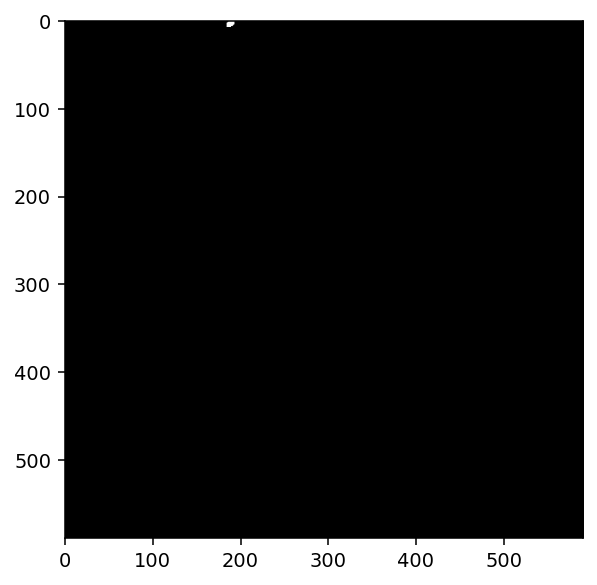

Min value = 80.0
Max value = 80.0
Mean value = 80.0


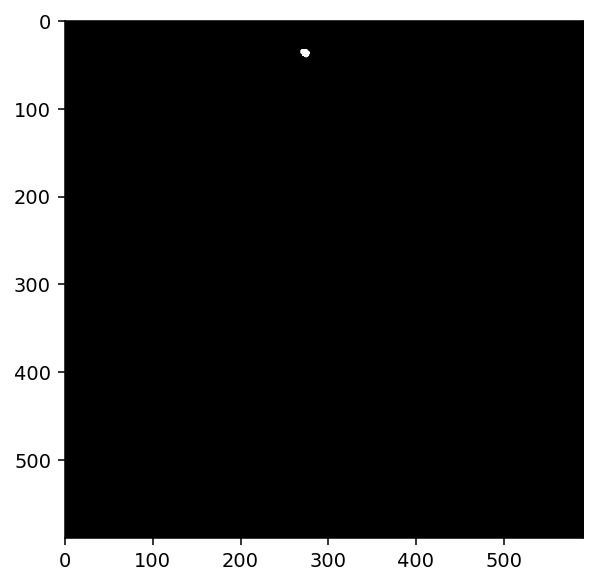

In [14]:
# Extract masks 
mask = results[0].masks.data.cpu().numpy()
mask = mask.astype(np.uint8)
mask_list = [mask[i] for i in range(mask.shape[0])]

# Filter mask size
filtered_area = [pcv.filters.obj_props(bin_img=m, cut_side="lower", thresh=1000, regprop="area") for m in mask_list]
filtered_area1 = [pcv.filters.obj_props(bin_img=m, cut_side="upper", thresh=50, regprop="area") for m in filtered_area]

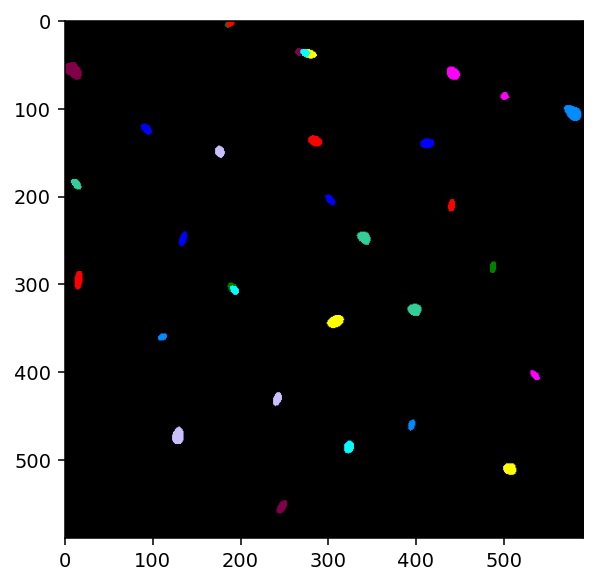

In [15]:
labeled_mask, colored_img, num_label = pcv.masks2labels(filtered_area1)

# View the isolated objects, stomata in this case

## to launch a Napari viewer with the overlay uncomment the code block below.
![overlay img](./img/overlay-segmentation.png)

In [17]:
##Uncomment this code block if running this notebook locally or where a Napari viewer can be used if you want to view overlay of segemented image with image.

#viewer3=pcvan.napari_open(img)
#viewer3.add_image(colored_img, opacity=0.5)

## Get seed size, shape, and color characteristics with PlantCV

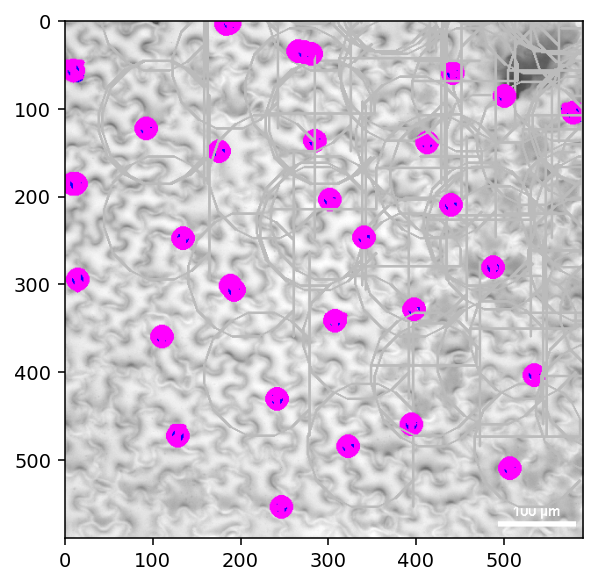

In [22]:
shape_image = pcv.analyze.size(img=img, labeled_mask=labeled_mask, n_labels=num_label)

In [25]:
# Write size data to results file

pcv.outputs.save_results(filename=args.result, outformat="json")